## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_quantile"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "quantile"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


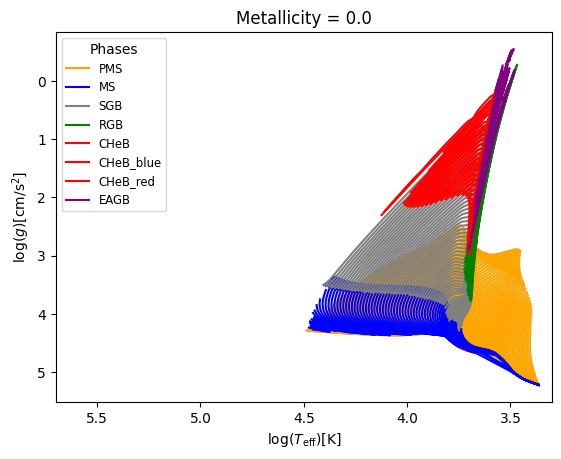

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


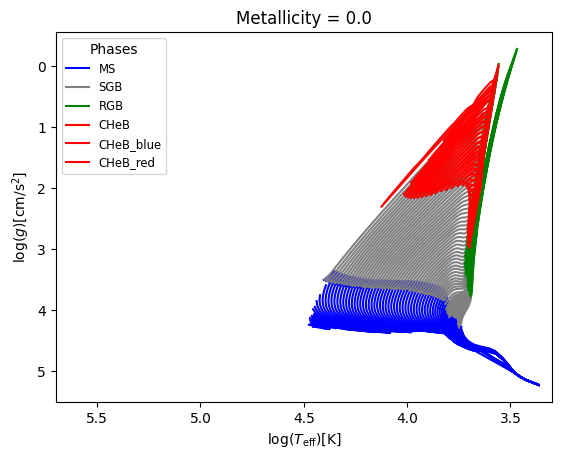

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.0428, Median : 9.3

logTe  : Range : 3.36 - 4.5177, Mean : 3.7779, Median : 3.721

logg  : Range : -0.38 - 5.345, Mean : 2.7607, Median : 2.486

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.6725, Median : 1.428

Rpol  : Range : -0.98 - 2.8373, Mean : 0.9648, Median : 1.0158



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.5306106500787039
  RMSE :  2.1037757747687986
  MAE :  1.6418829371006742
  MedAE :  1.461716633487132
  CORR :  0.7390219346171308
  MAX_ER :  8.431178043129059
  Percentiles : 
    75th percentile :  2.1259698747733715
    90th percentile :  2.9489696609134763
    95th percentile :  4.127702535994354
    99th percentile :  6.991785508184961

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.6620862726444166
  RMSE :  1.9604476364131473
  MAE :  1.4952441019935536
  MedAE :  1.2730707610060716
  CORR :  0.8241633654209348
  MAX_ER :  7.550840540200158
  Percentiles : 
    75th percentile :  1.6722259998614184
    90th percentile :  3.0884405037443705
    95th percentile :  4.520715574037924
    99th percentile :  6.235324534784302

mass 

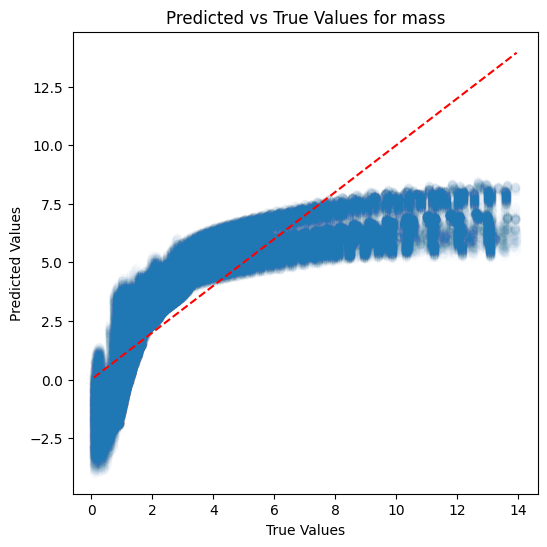

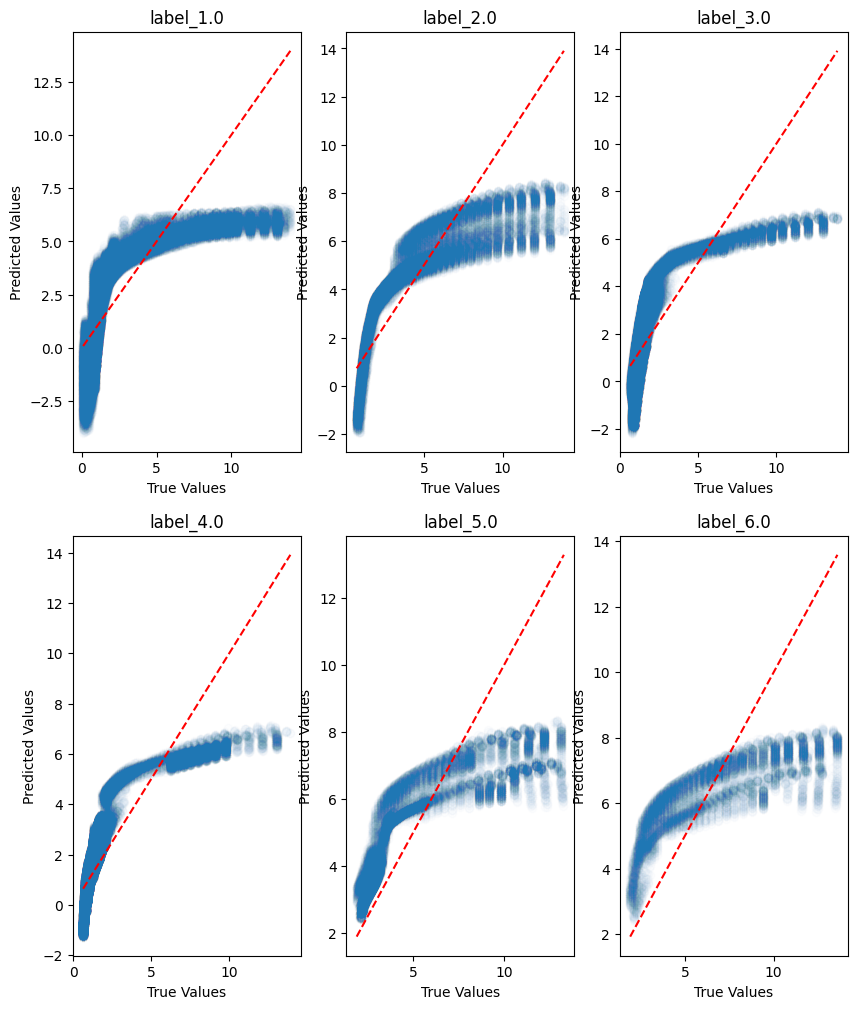

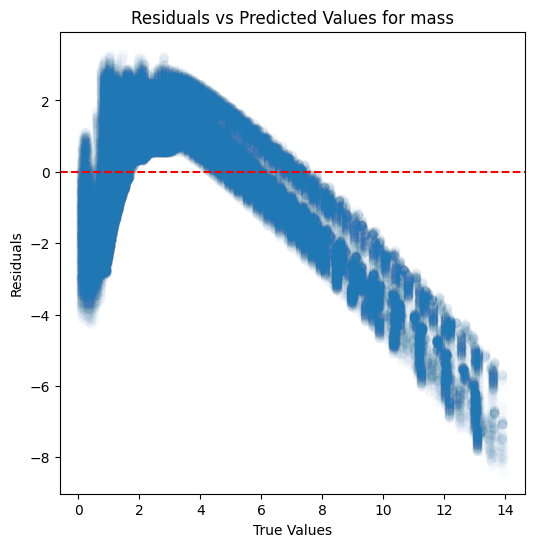

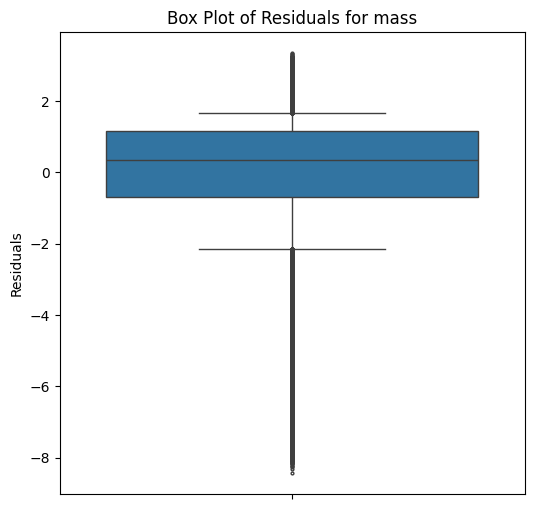

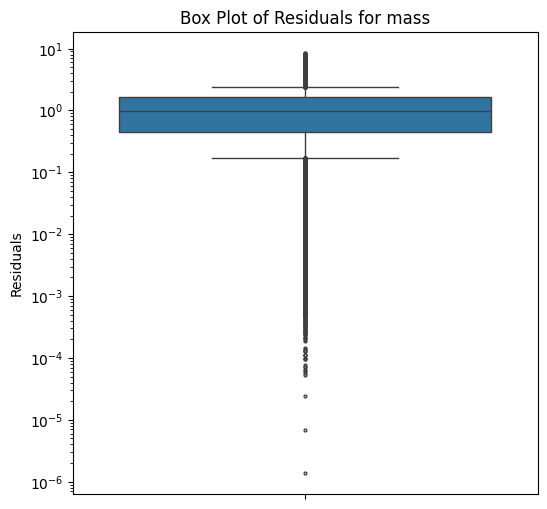

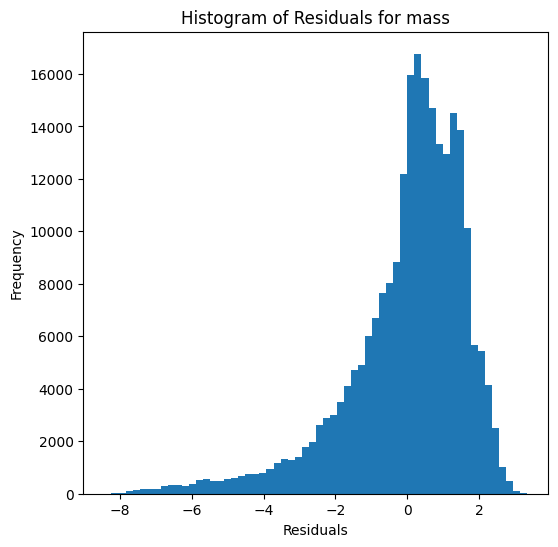

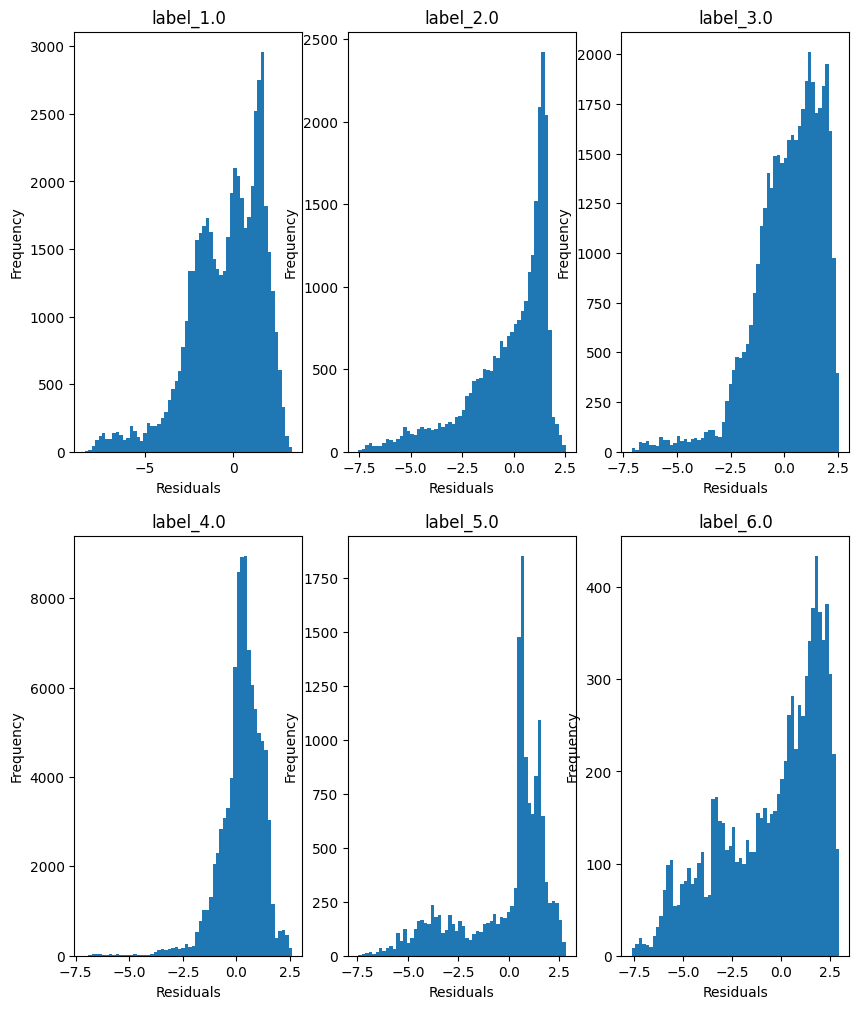

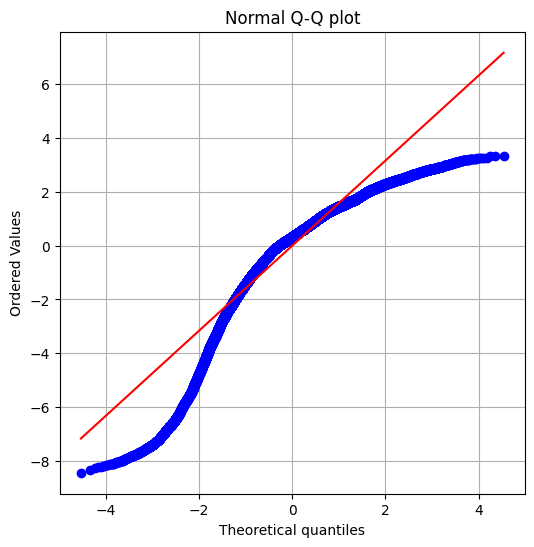

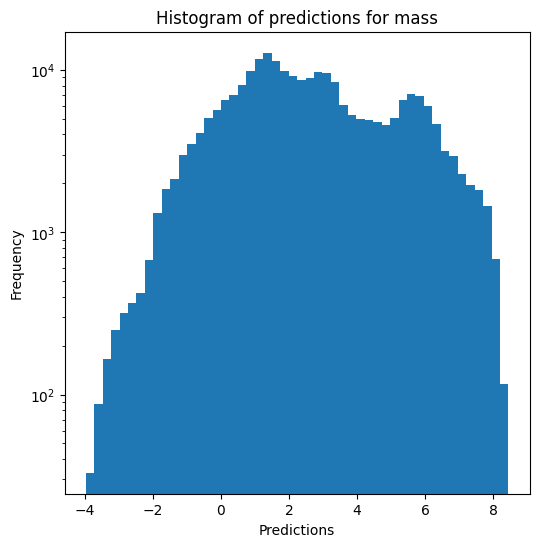

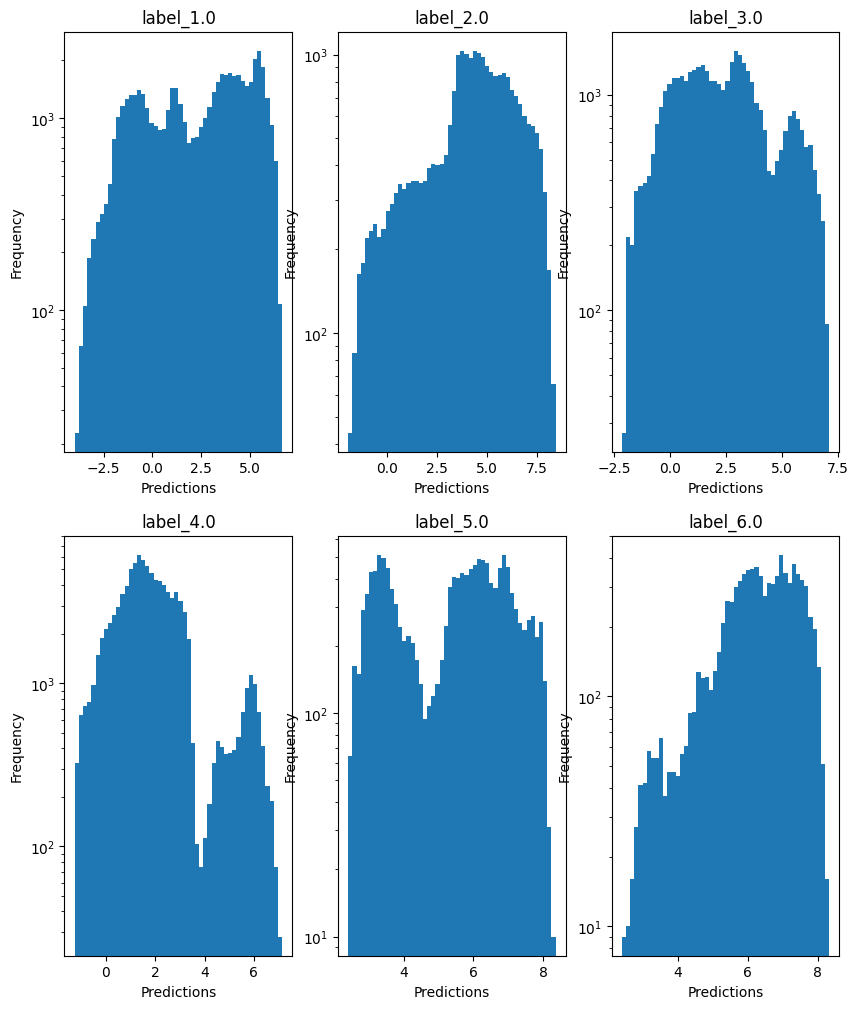

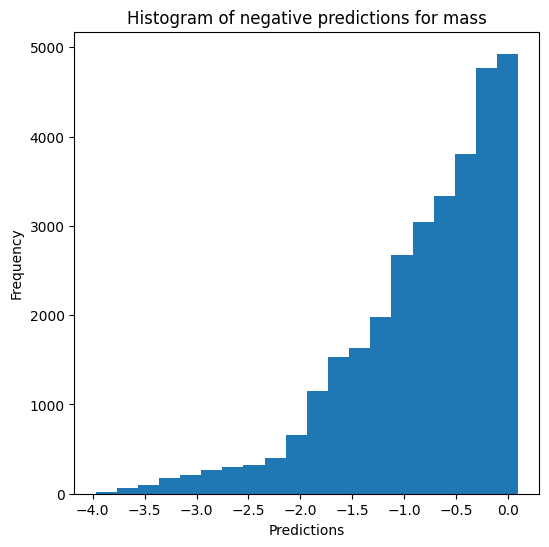


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.7452377214726131
  RMSE :  0.22967544456128688
  MAE :  0.15684590584276217
  MedAE :  0.10656288041932285
  CORR :  0.8764070943157656
  MAX_ER :  1.0059932217486884
  Percentiles : 
    75th percentile :  0.19957367306959353
    90th percentile :  0.331302970193203
    95th percentile :  0.53421455387992
    99th percentile :  0.8347736915511157

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9051417438905617
  RMSE :  0.17666286757964936
  MAE :  0.14162244973087448
  MedAE :  0.11420865562324145
  CORR :  0.9567406075882751
  MAX_ER :  0.4938047359814437
  Percentiles : 
    75th percentile :  0.22526594215024814
    90th percentile :  0.29678017927658934
    95th percentile :  0.33460752402797145
    99th percentile :  0.40243608906639516

radius results for the label category w

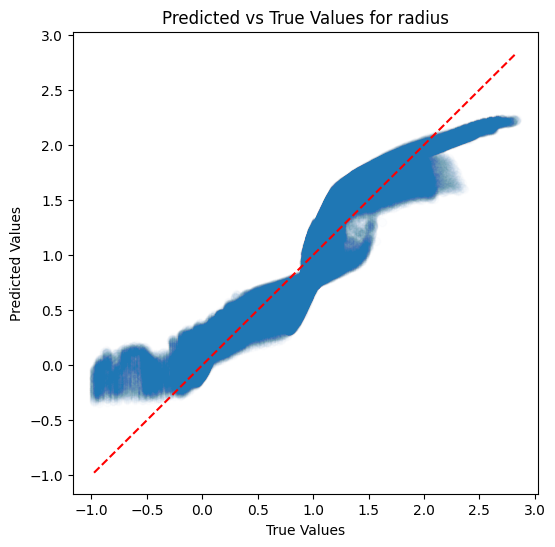

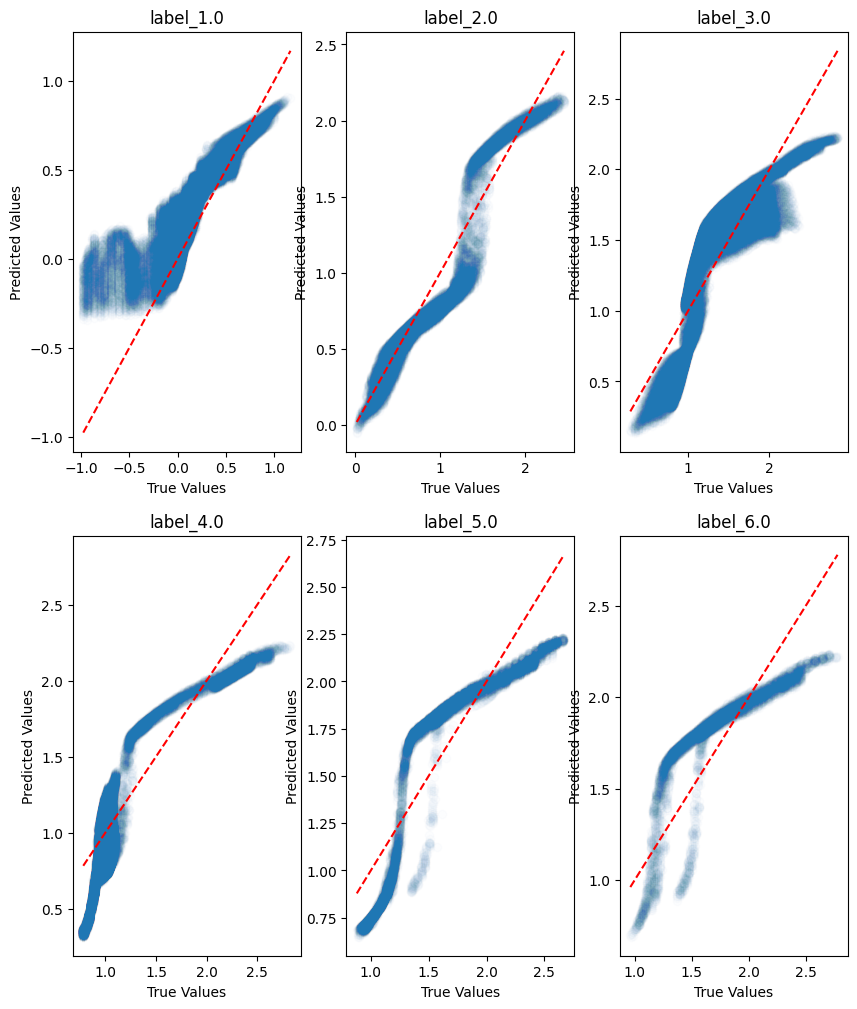

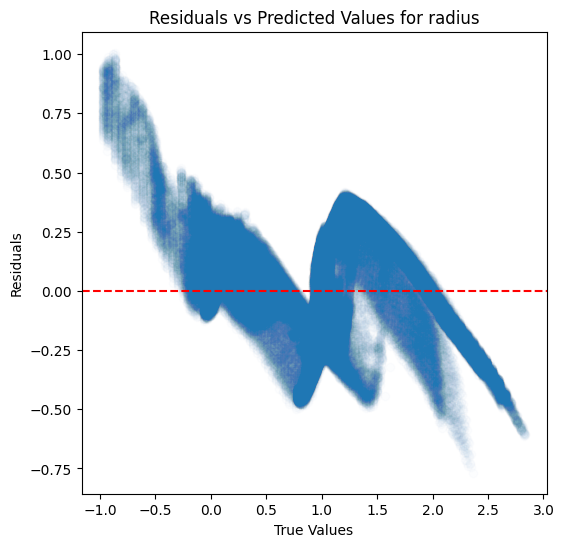

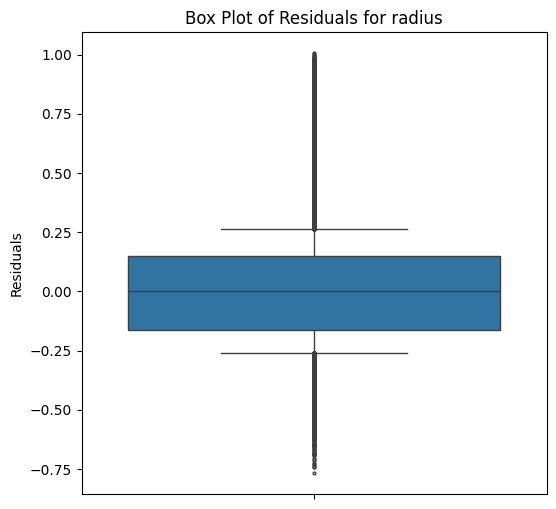

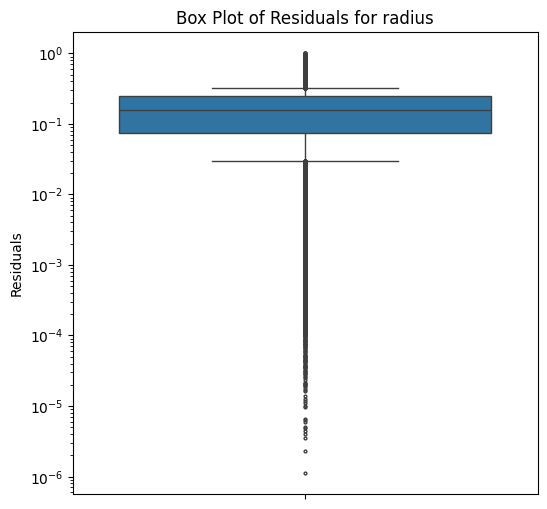

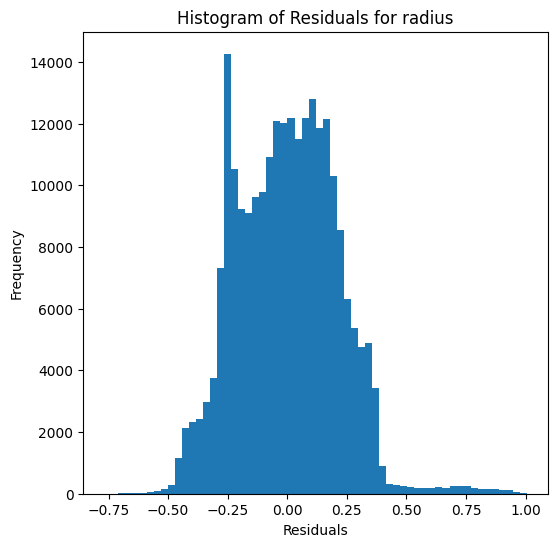

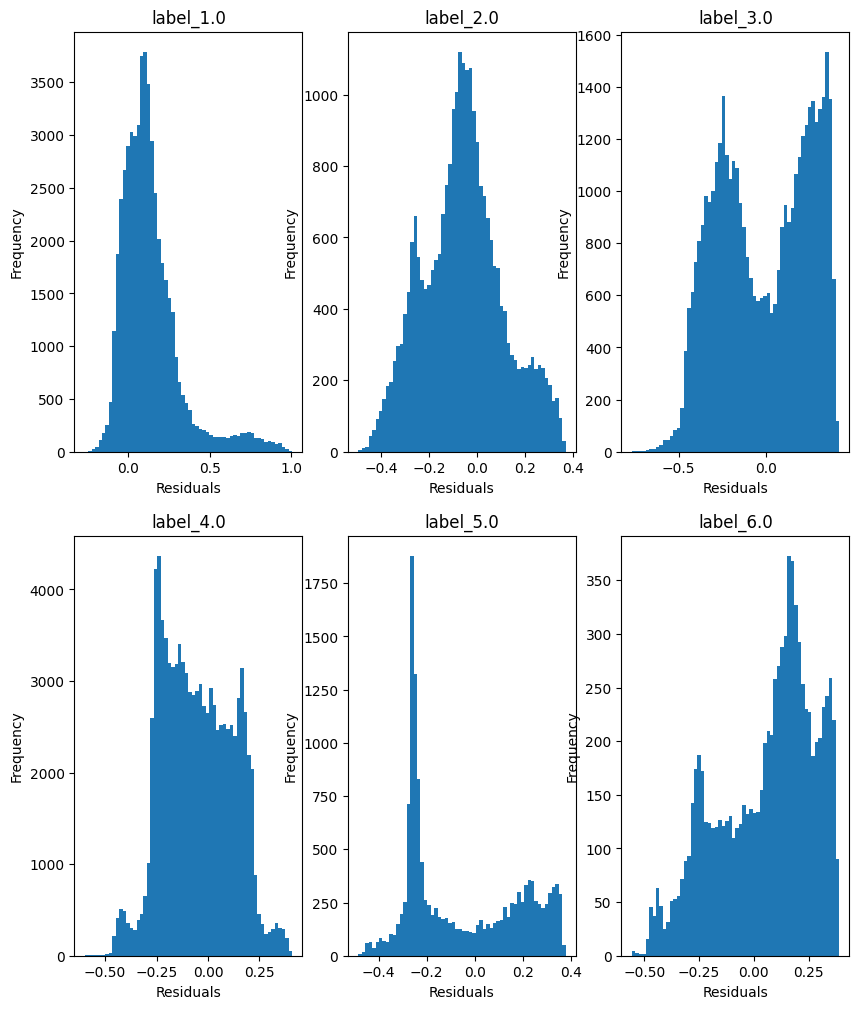

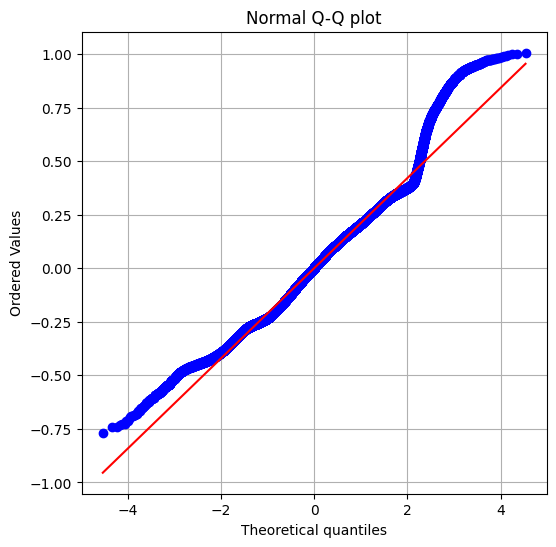

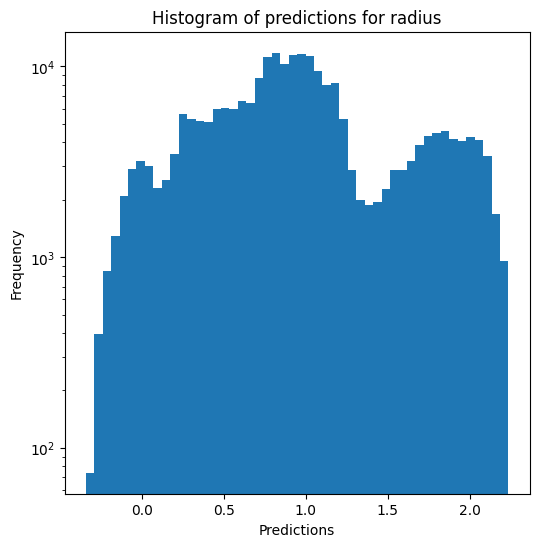

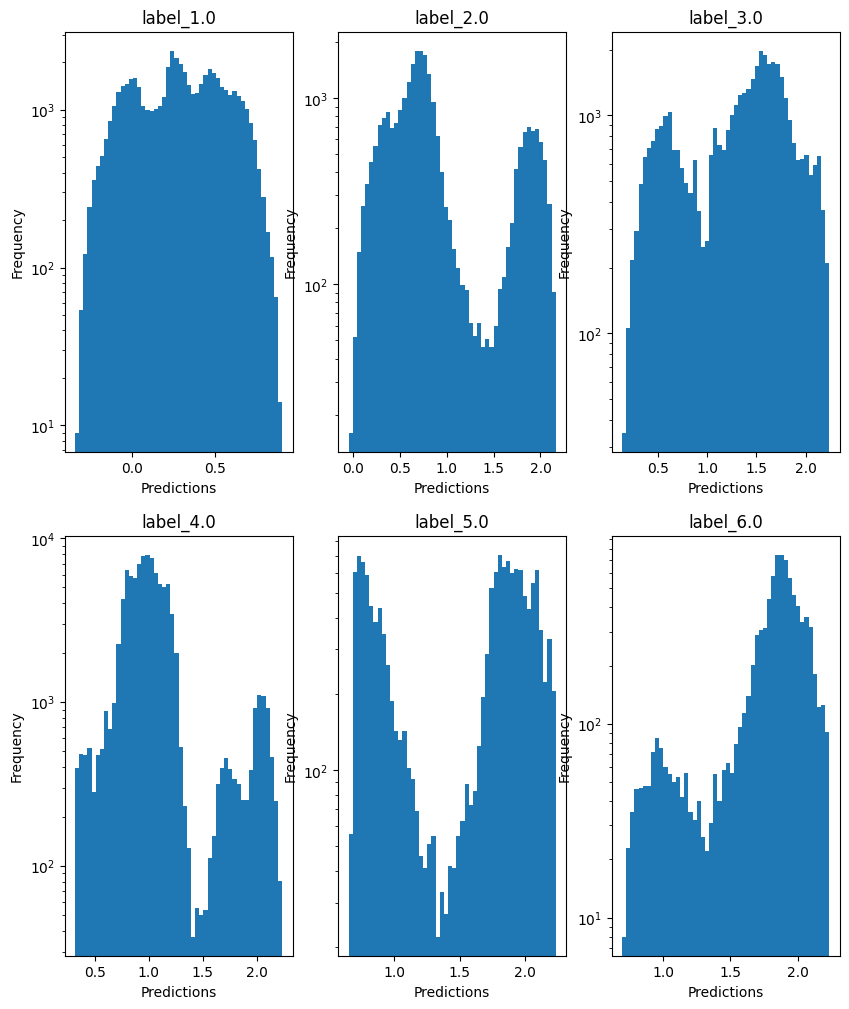

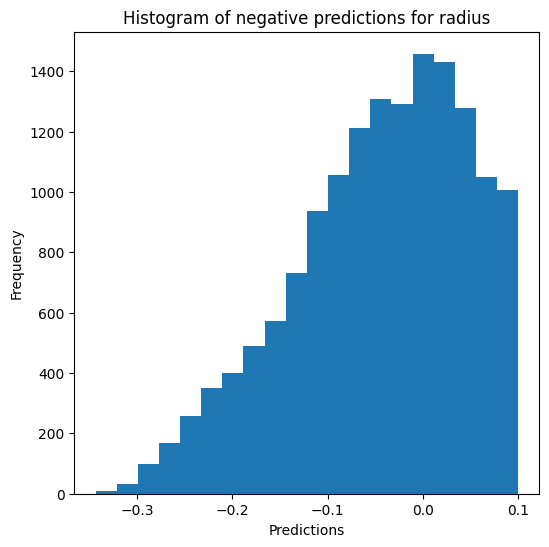

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9996186473237151
  RMSE :  0.058928651181218074
  MAE :  0.013670537891463332
  MedAE :  0.0
  CORR :  0.9998093269973084
  MAX_ER :  1.2390000000000008
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.021999999999999797
    95th percentile :  0.07000000000000028
    99th percentile :  0.2970000000000006

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999382057570886
  RMSE :  0.026356328948384706
  MAE :  0.006569978301301951
  MedAE :  0.0
  CORR :  0.999969235352901
  MAX_ER :  0.9060000000000006
  Percentiles : 
    75th percentile :  0.0009999999999998899
    90th percentile :  0.017000000000000348
    95th percentile :  0.042649999999997586
    99th percentile :  0.10400000000000004

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.999915297377

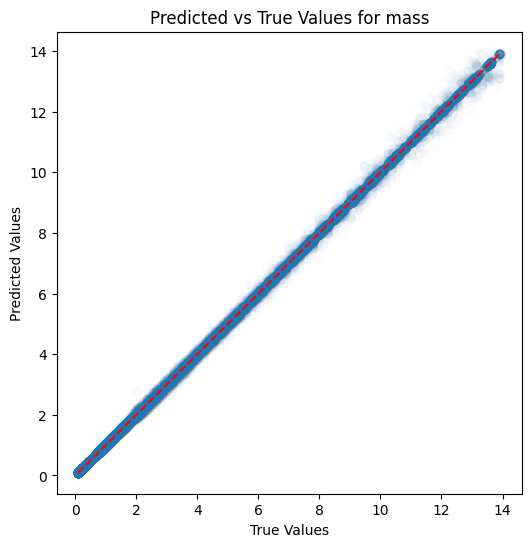

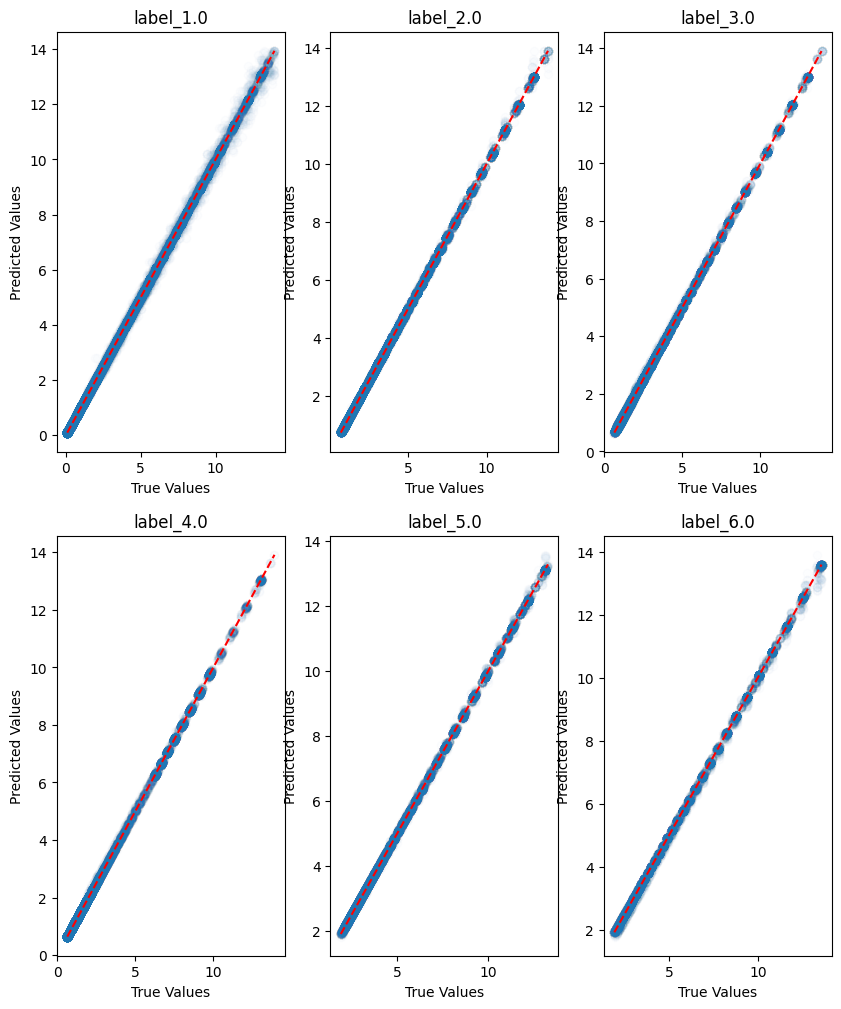

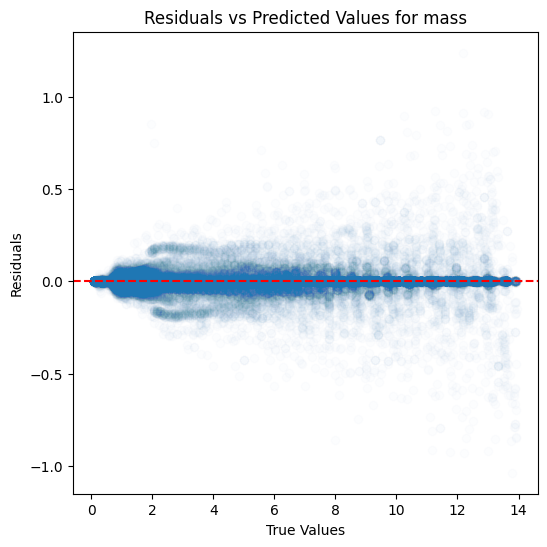

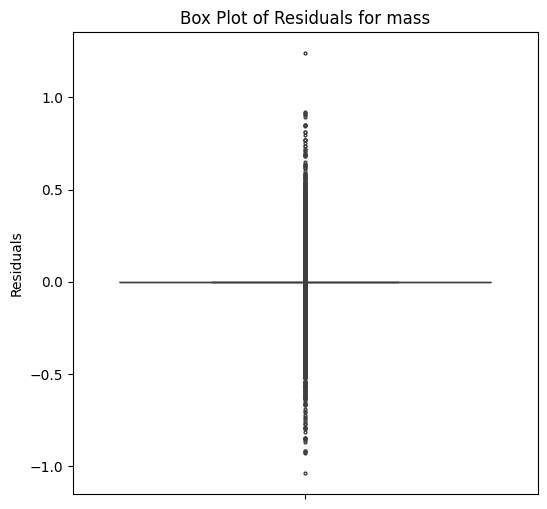

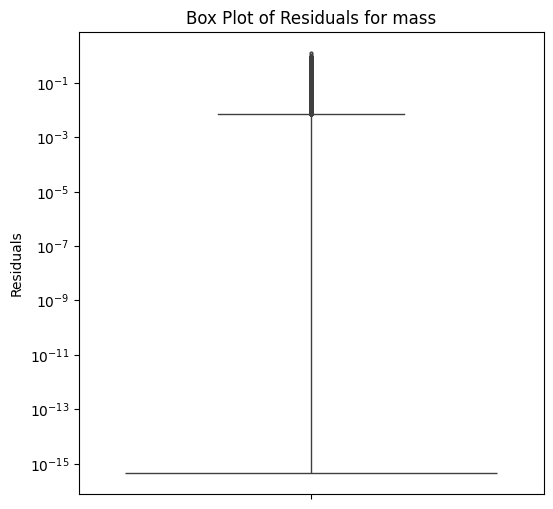

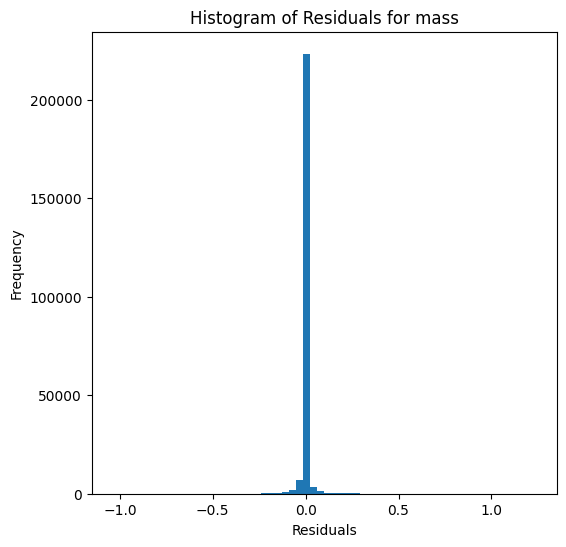

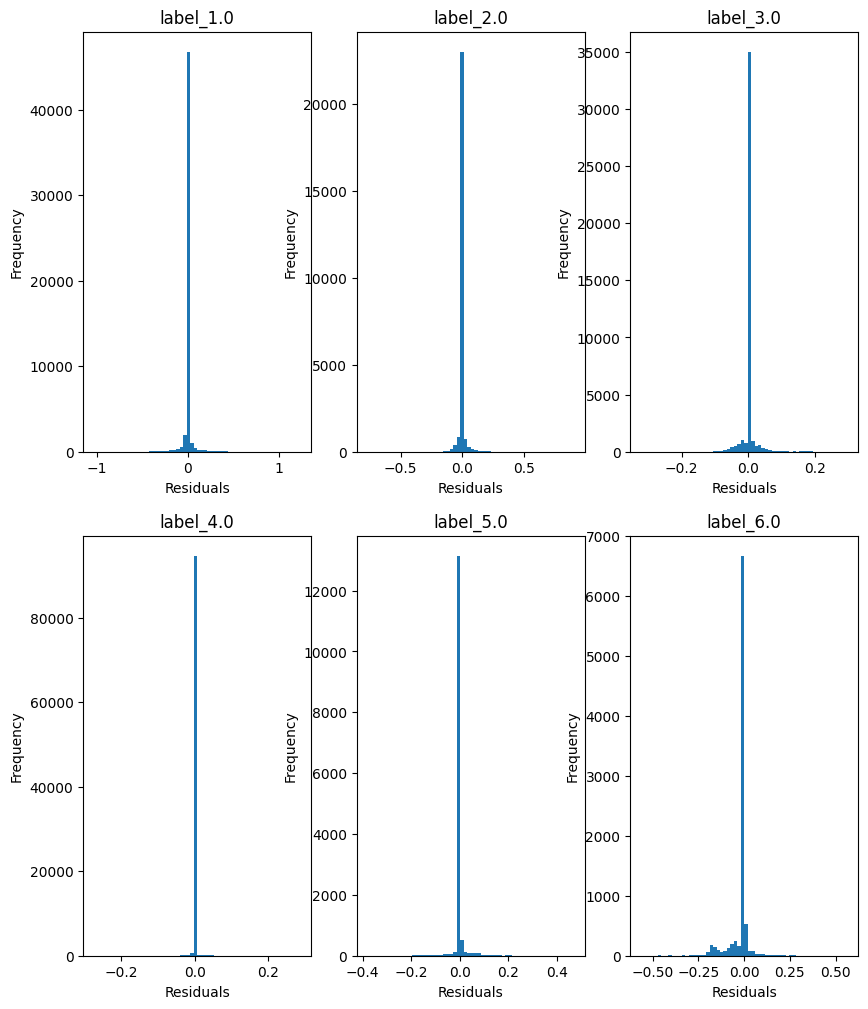

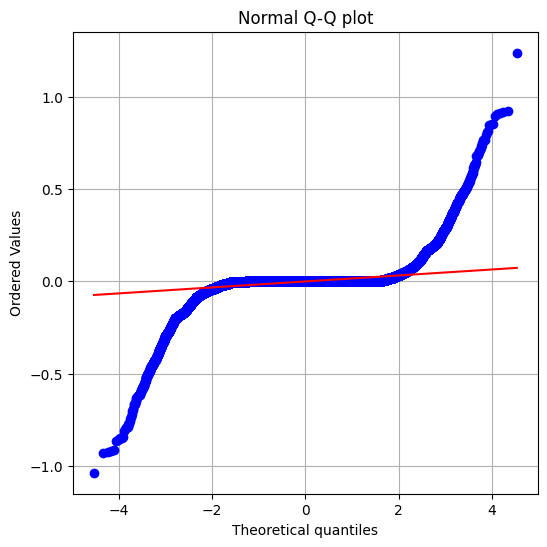

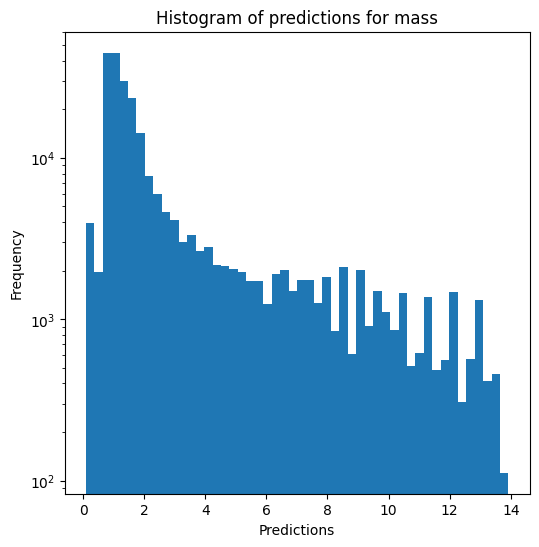

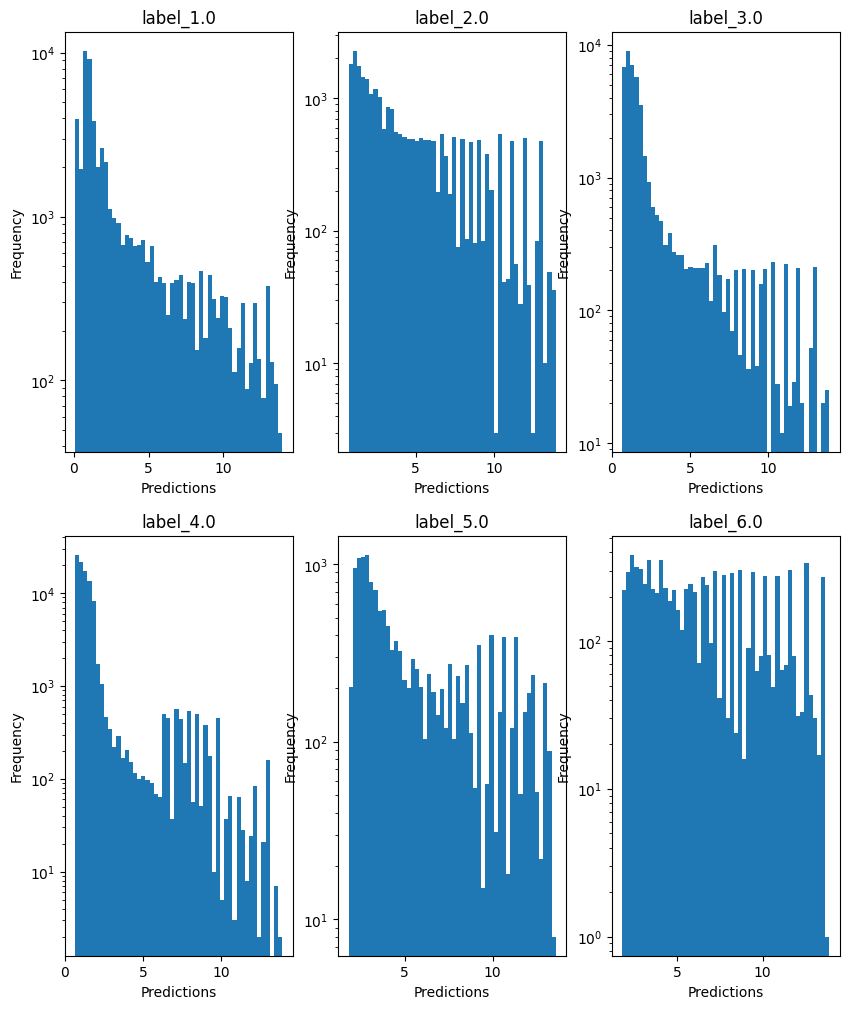

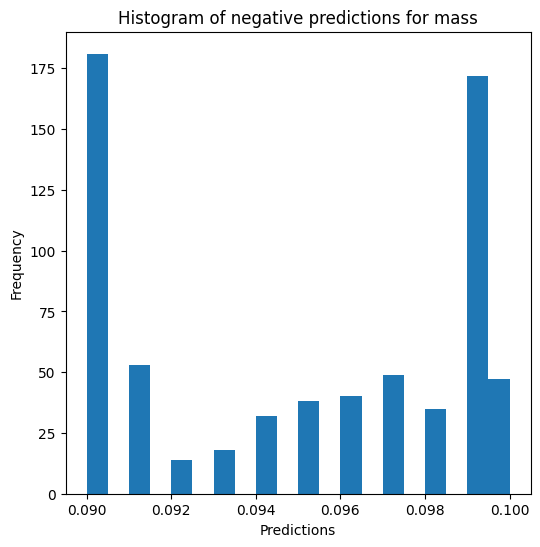

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996366719849652
  RMSE :  0.006975916105043043
  MAE :  0.0025473939065645407
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998184253497757
  MAX_ER :  0.11918640771920858
  Percentiles : 
    75th percentile :  0.0017547275665504847
    90th percentile :  0.007613564491801339
    95th percentile :  0.013783677637519975
    99th percentile :  0.032737272876583616

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9992896159926047
  RMSE :  0.014425150368764643
  MAE :  0.005624199337857754
  MedAE :  0.0
  CORR :  0.9996485336744827
  MAX_ER :  0.3414392883462989
  Percentiles : 
    75th percentile :  0.006828451152217474
    90th percentile :  0.019598311310704775
    95th percentile :  0.025858759548989012
    99th percentile :  0.04781385940466171

radius results for the label cat

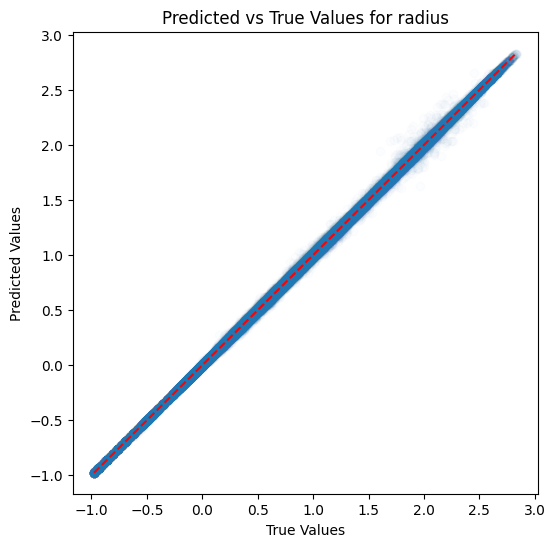

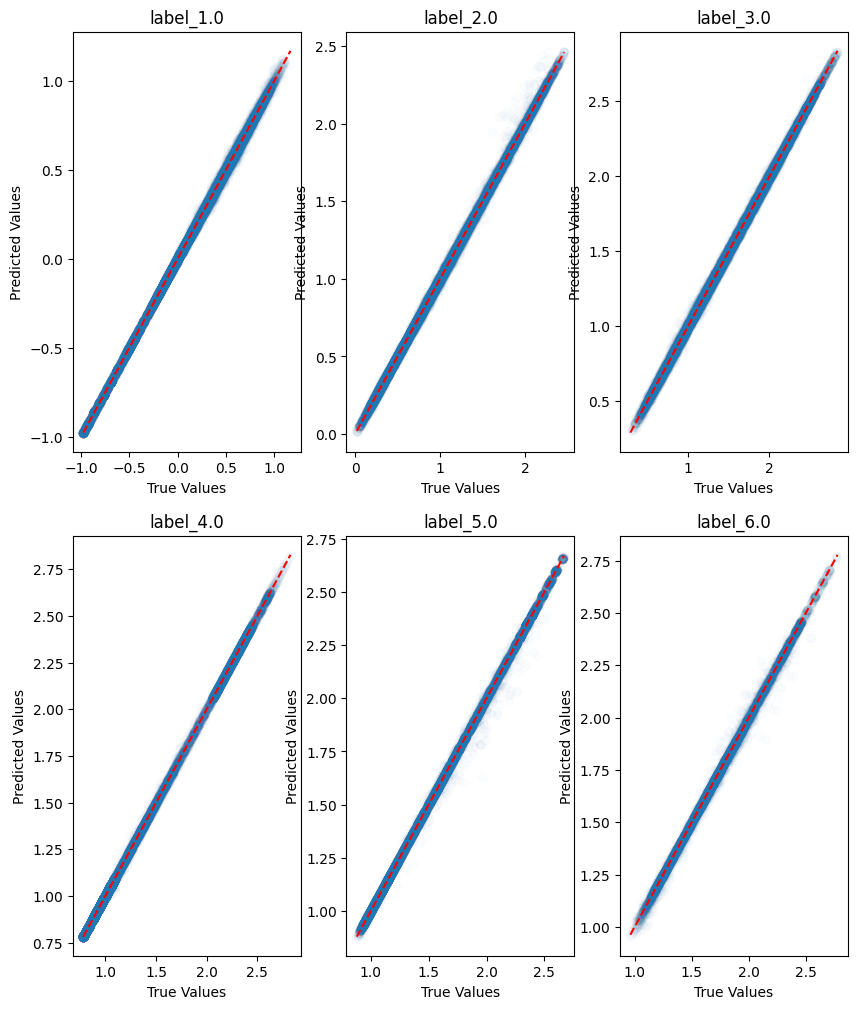

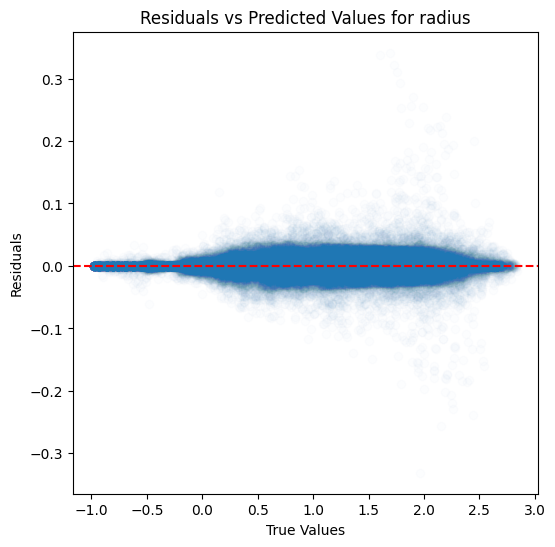

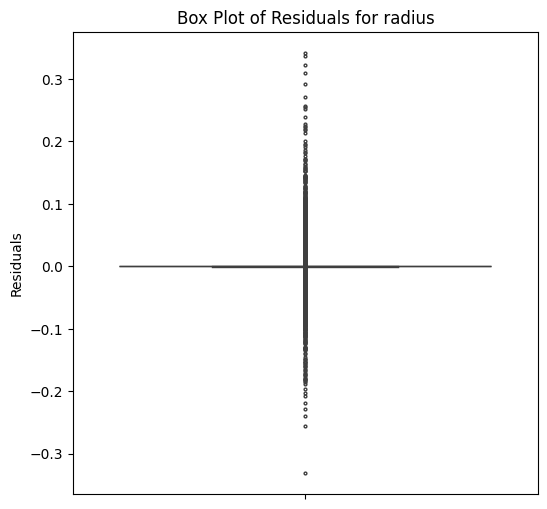

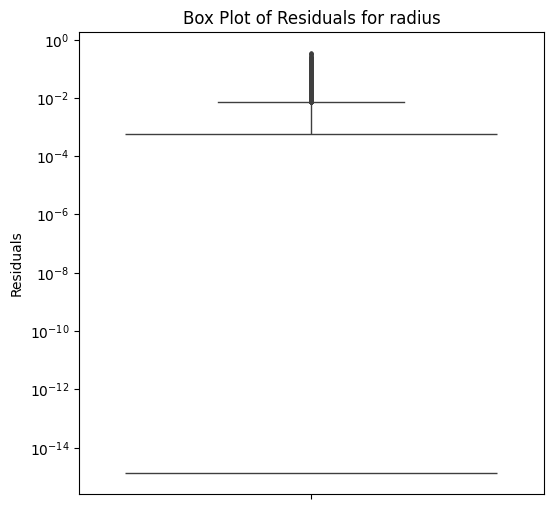

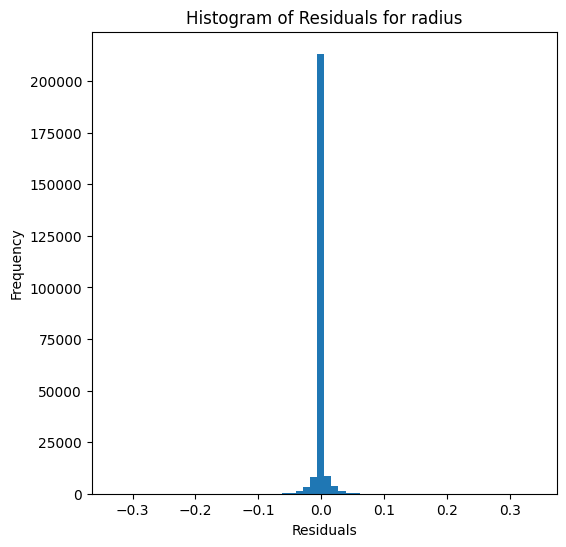

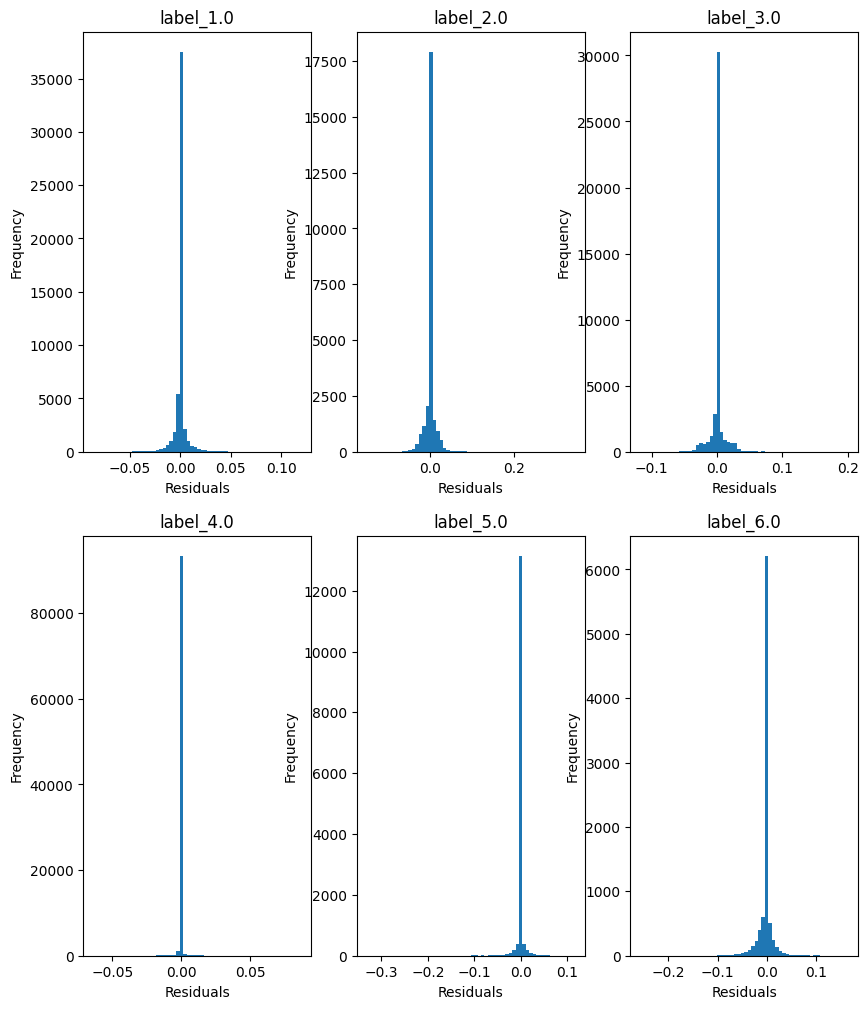

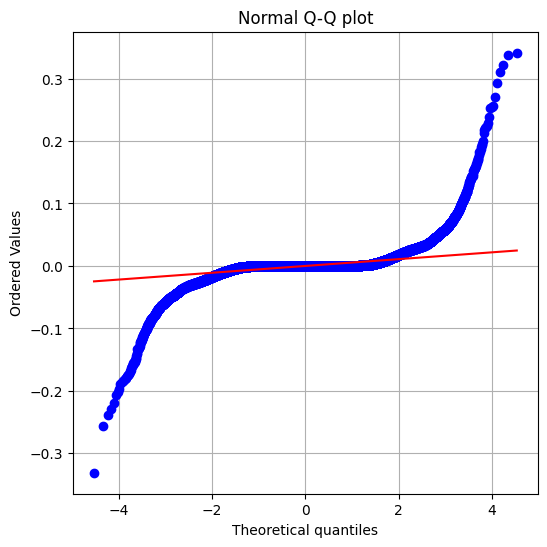

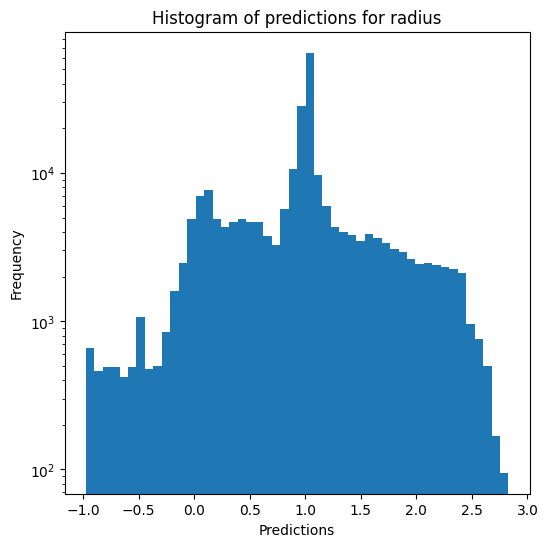

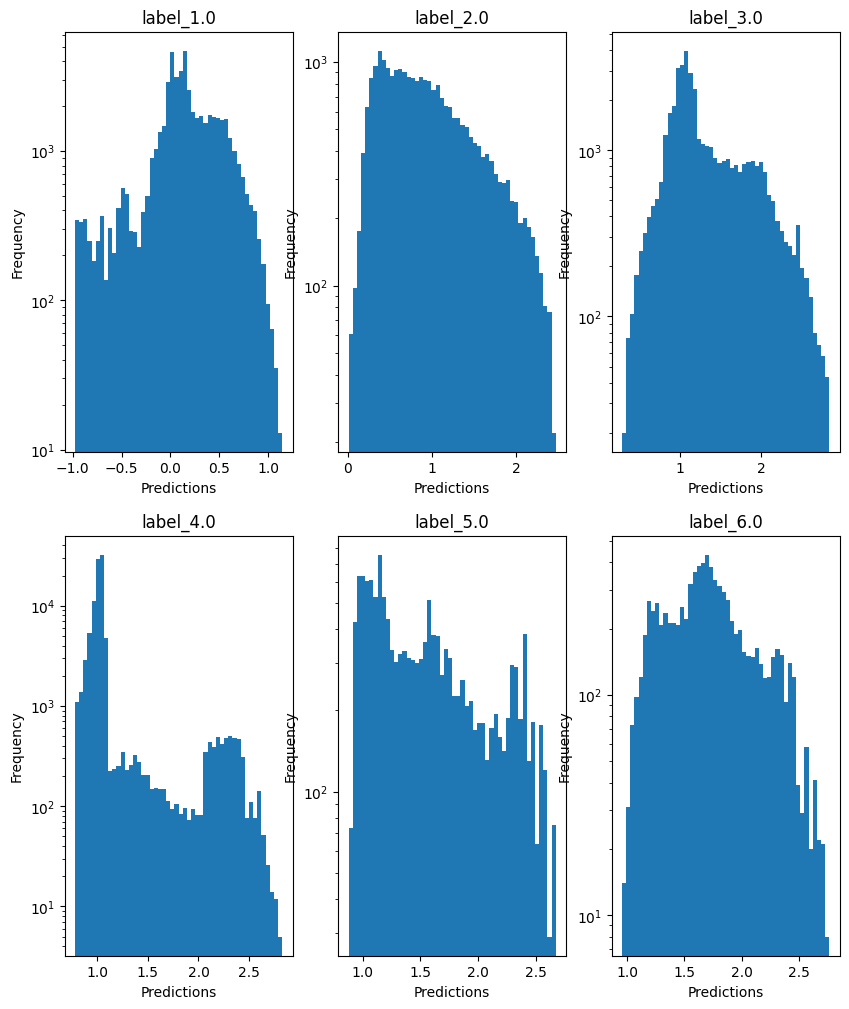

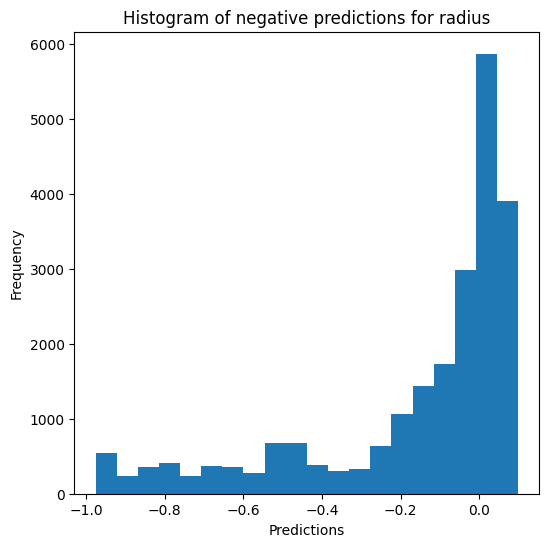

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.998162844289721
  RMSE :  0.12941880643318715
  MAE :  0.04821488837509002
  MedAE :  0.011400000000000077
  CORR :  0.9990815526001542
  MAX_ER :  2.284200000000002
  Percentiles : 
    75th percentile :  0.04214999999999991
    90th percentile :  0.11559999999999926
    95th percentile :  0.20519999999999983
    99th percentile :  0.6011499999999985

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9963934837357021
  RMSE :  0.20245747698615815
  MAE :  0.08635198388096714
  MedAE :  0.026000000000000245
  CORR :  0.998238723631865
  MAX_ER :  3.1608
  Percentiles : 
    75th percentile :  0.08740000000000059
    90th percentile :  0.2198000000000005
    95th percentile :  0.35705999999999943
    99th percentile :  0.8677440000000011

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.99959

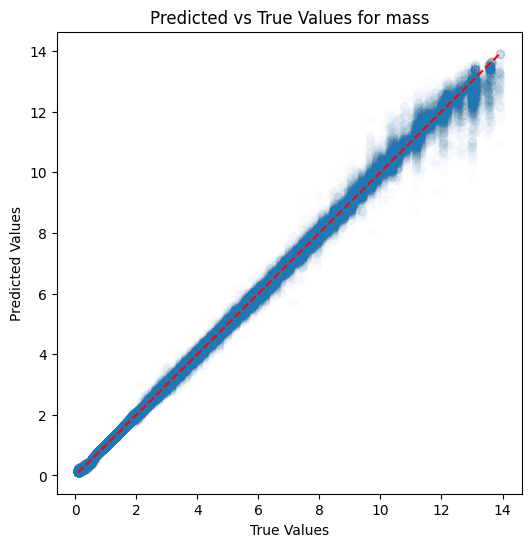

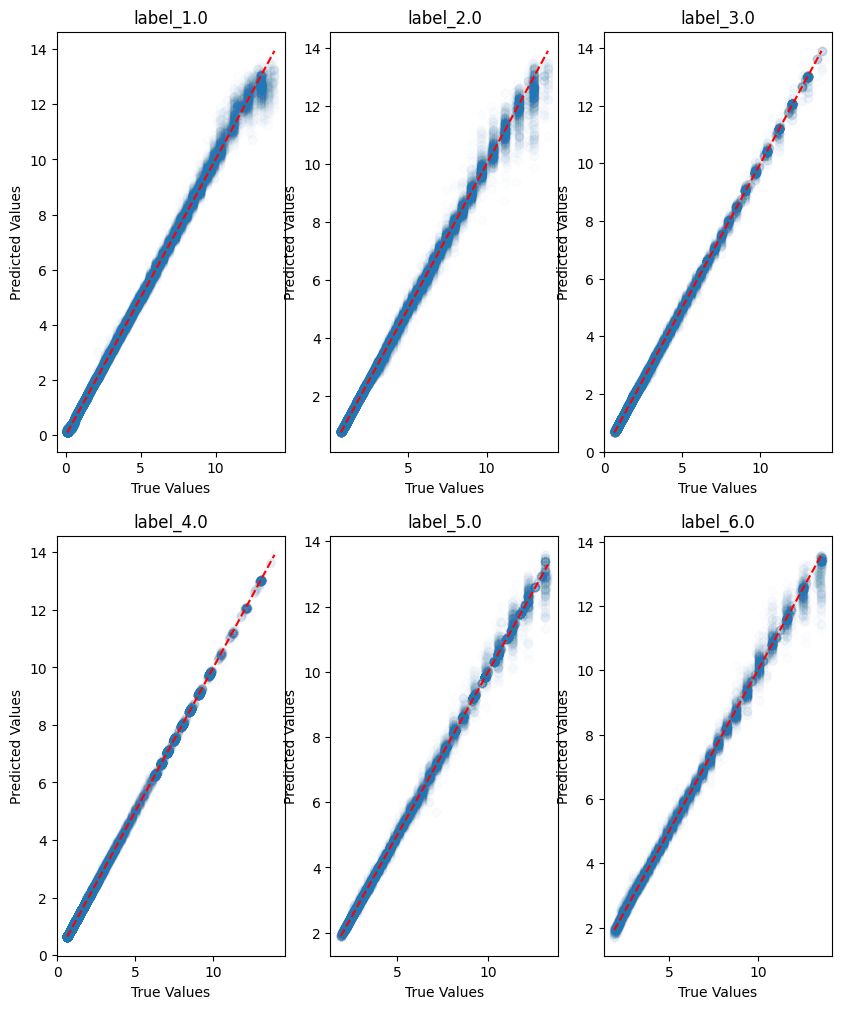

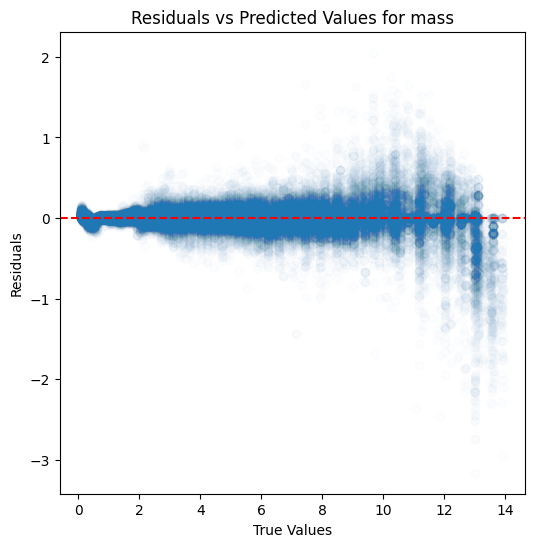

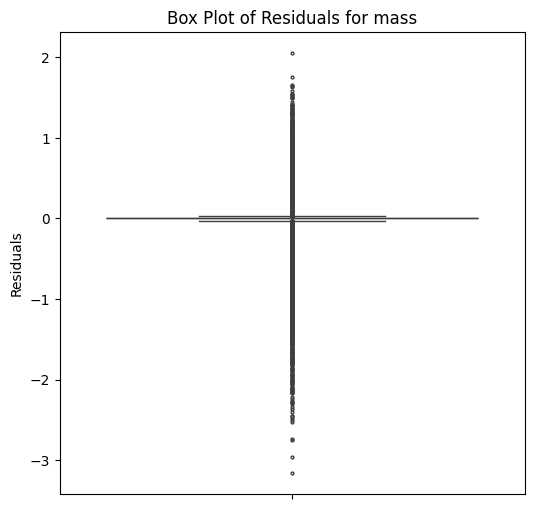

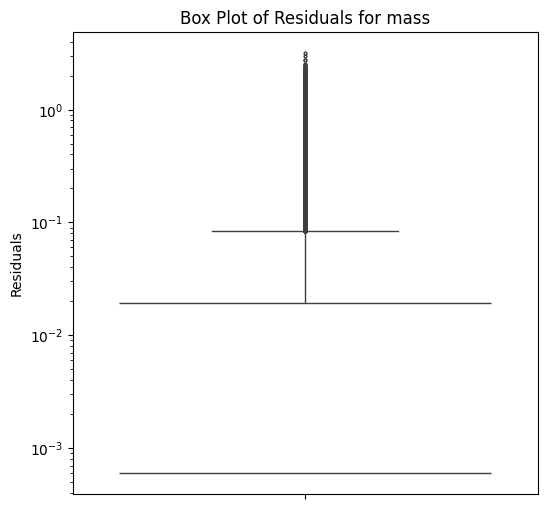

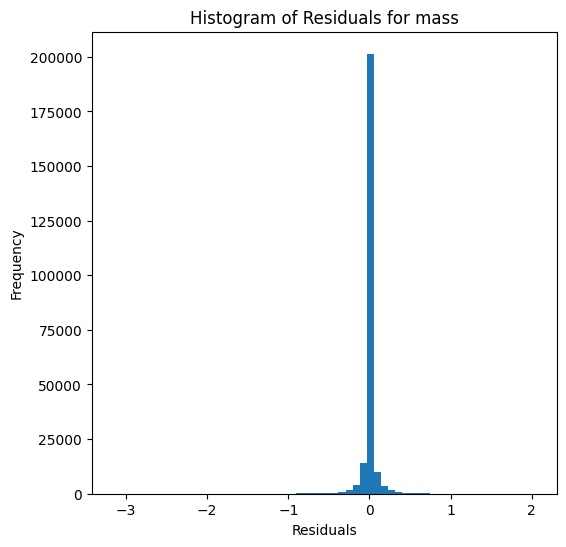

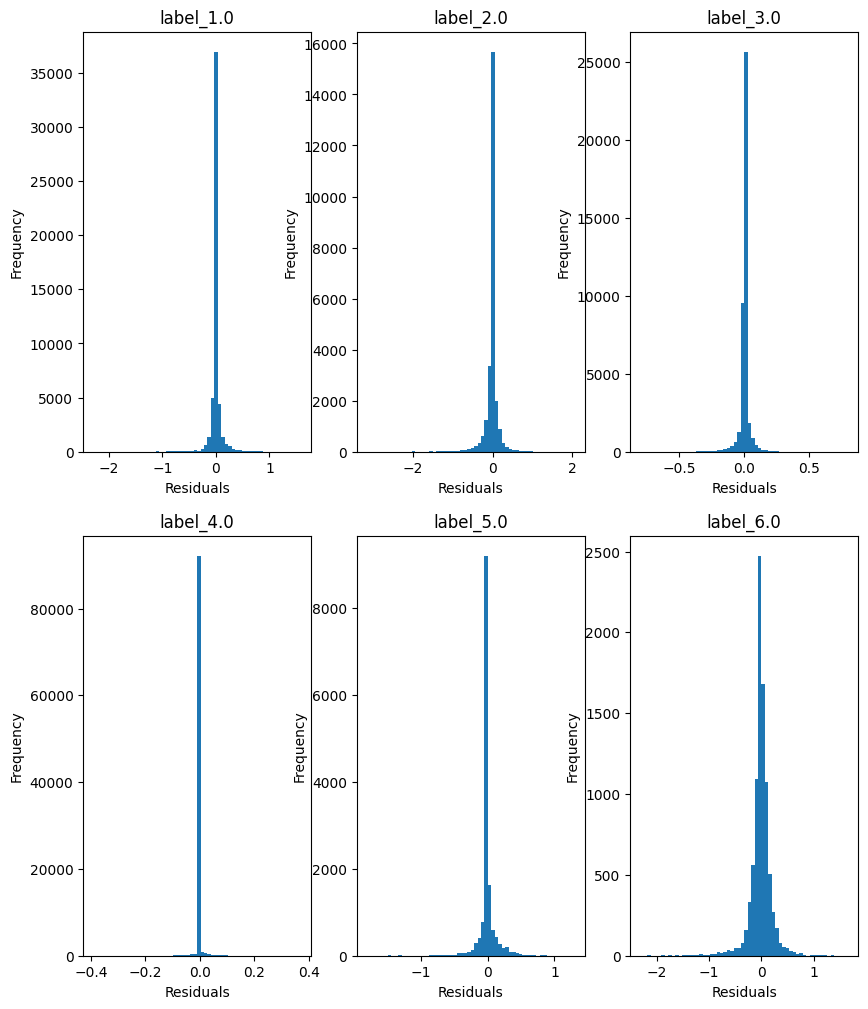

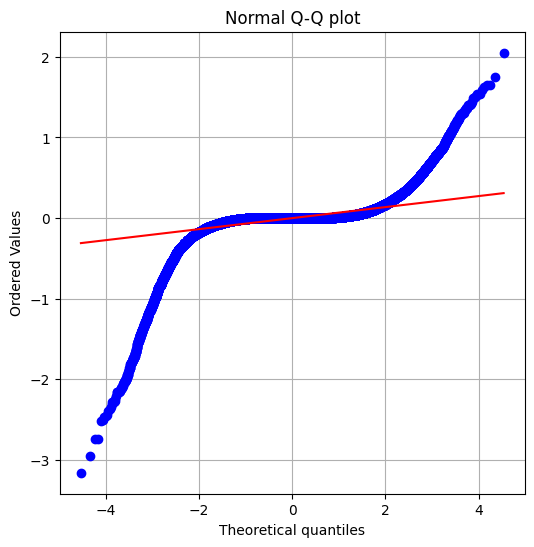

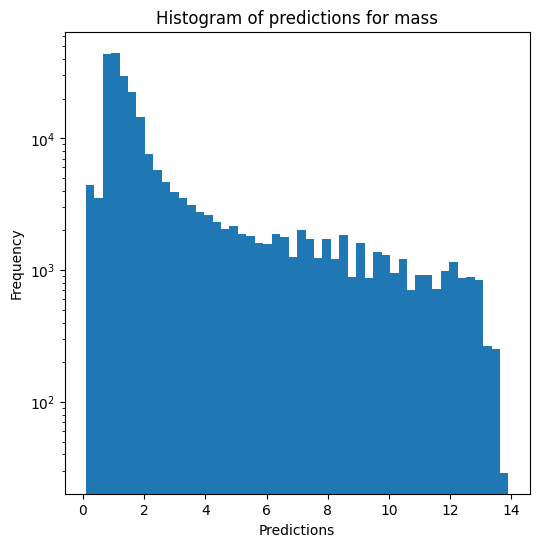

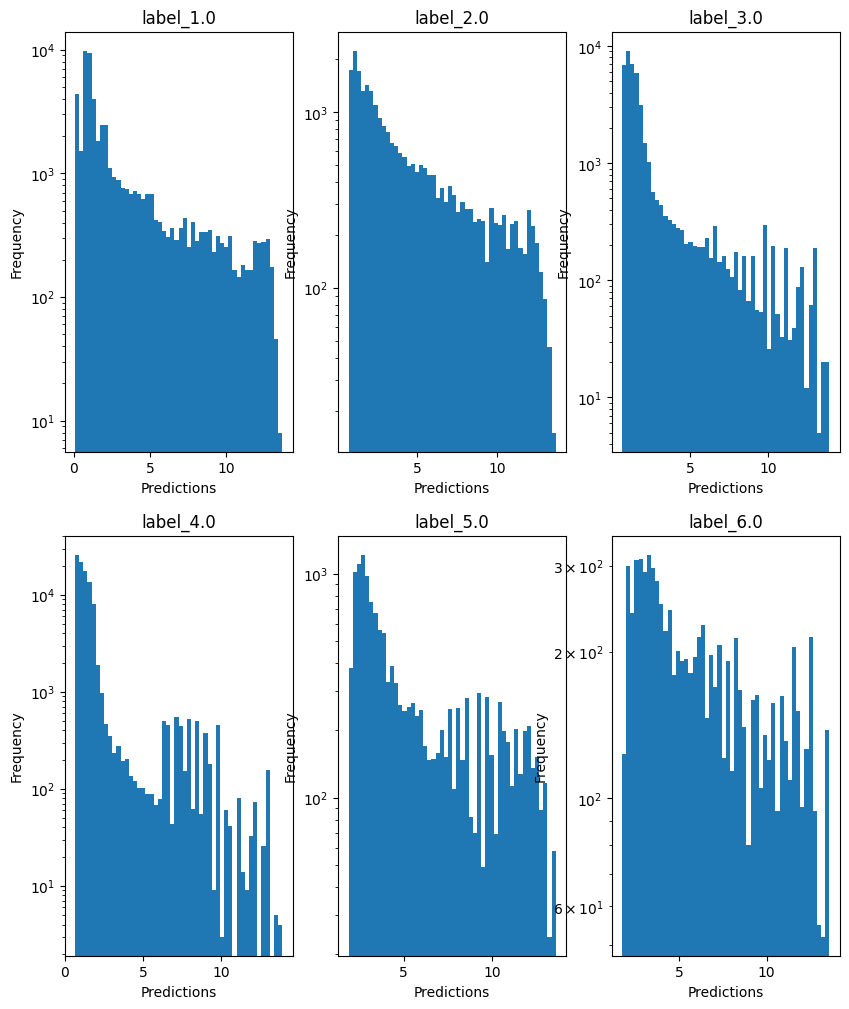

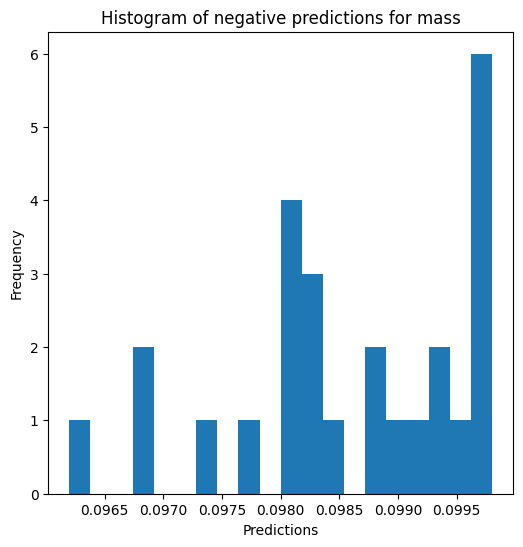


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9952834563746192
  RMSE :  0.025143805022337172
  MAE :  0.01024950461586721
  MedAE :  0.0037582445097771797
  CORR :  0.997639202807709
  MAX_ER :  0.3334426012574502
  Percentiles : 
    75th percentile :  0.009335891410566946
    90th percentile :  0.019657154195066306
    95th percentile :  0.042968071841835154
    99th percentile :  0.12679294545284042

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9983994502880393
  RMSE :  0.021794876491497656
  MAE :  0.013337161439086732
  MedAE :  0.008458698096812434
  CORR :  0.9993300965560925
  MAX_ER :  0.2492815826368029
  Percentiles : 
    75th percentile :  0.015957203998064357
    90th percentile :  0.027203959476815368
    95th percentile :  0.041267991371885436
    99th percentile :  0.09089206837874024

radius results for the

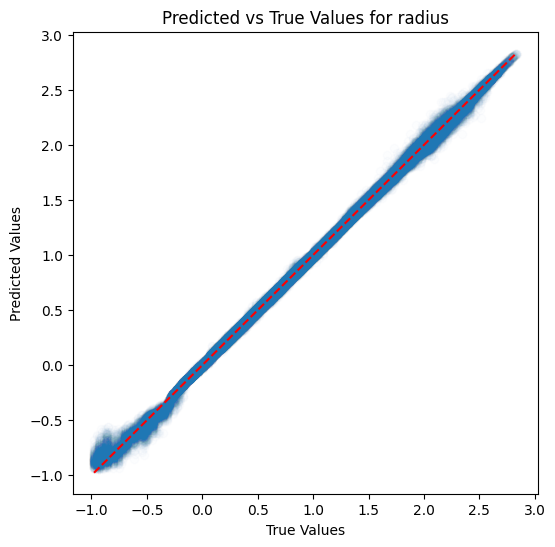

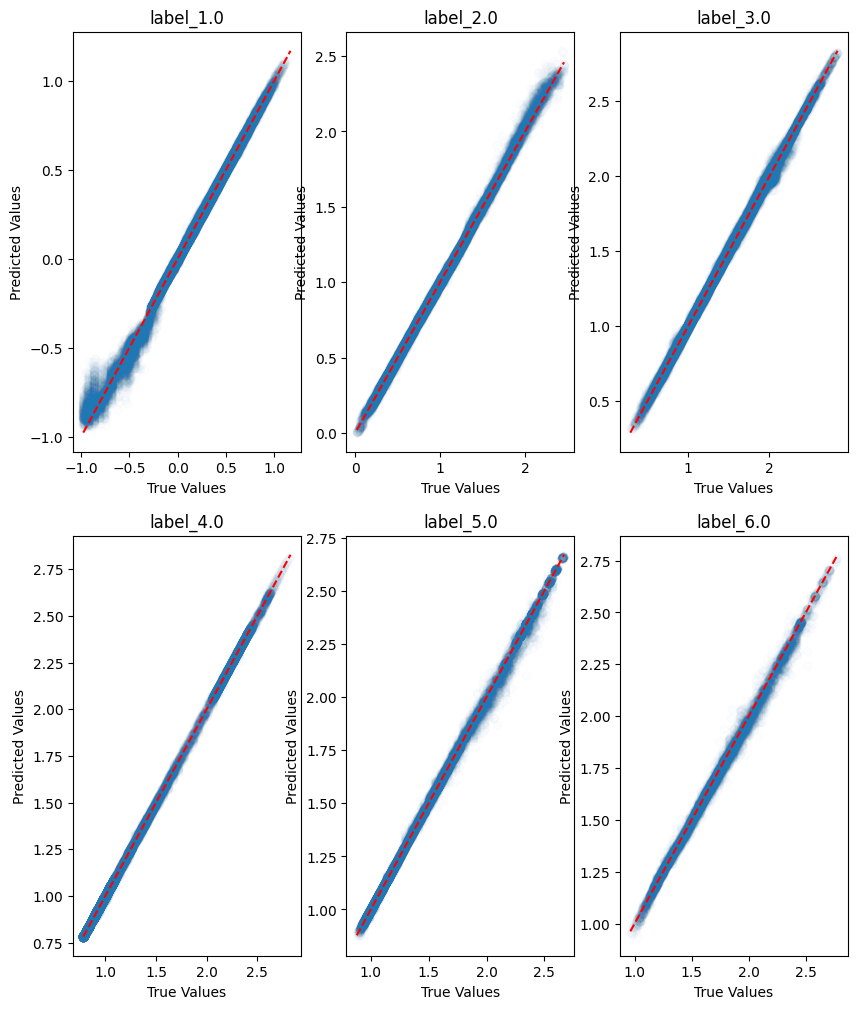

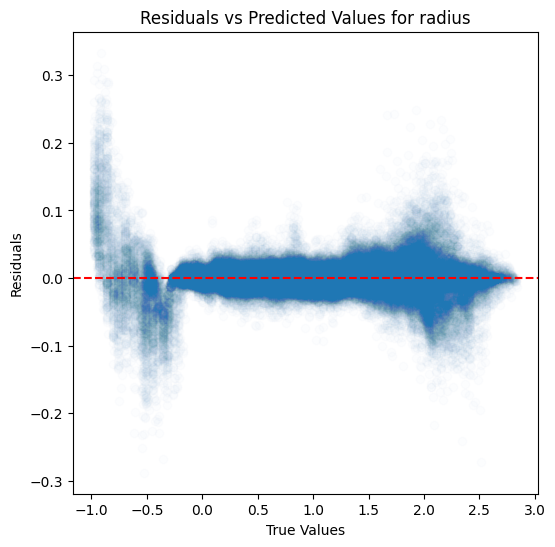

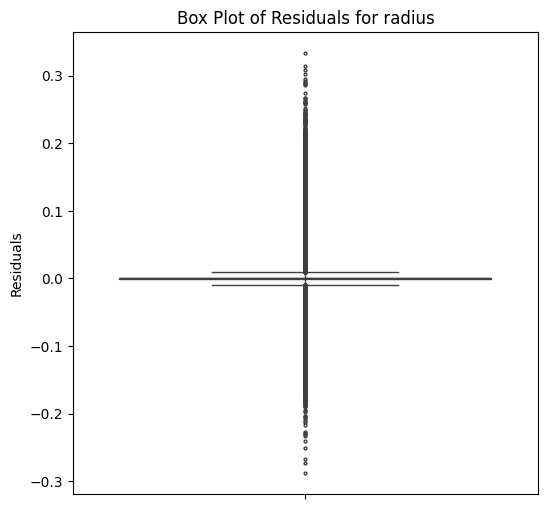

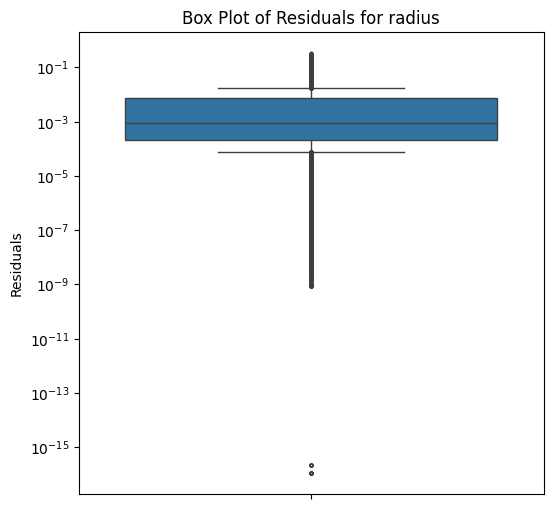

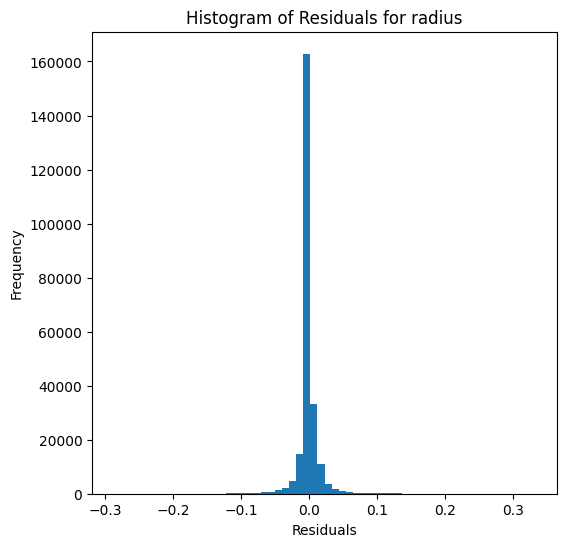

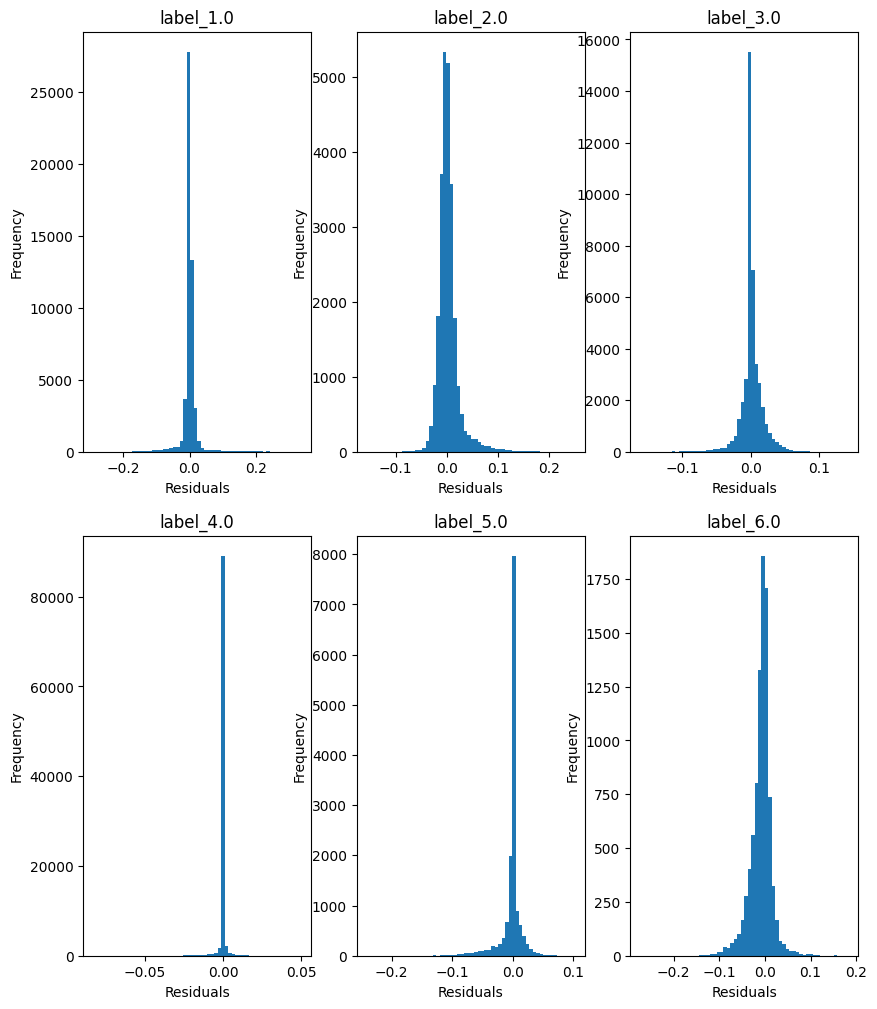

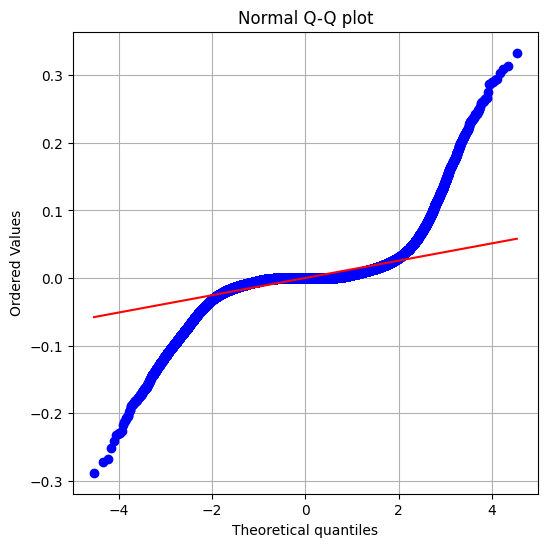

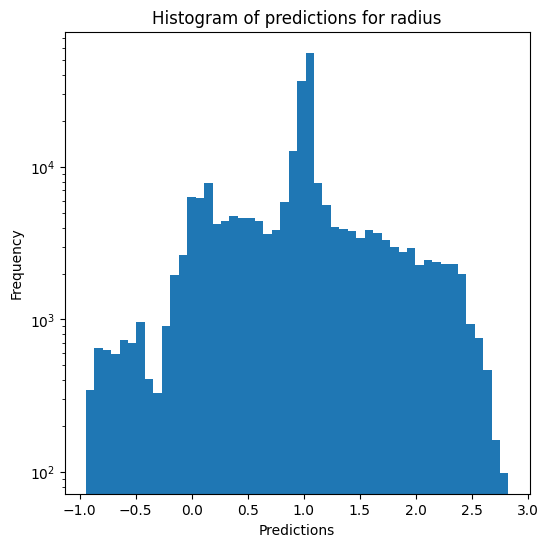

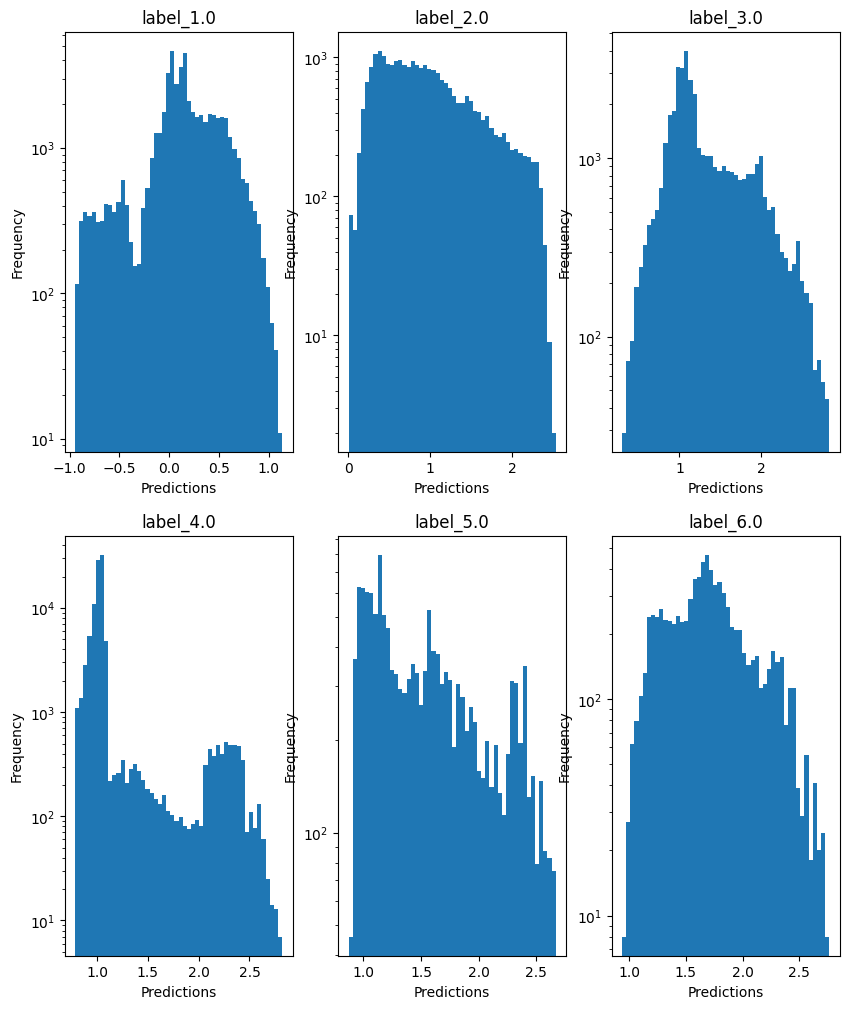

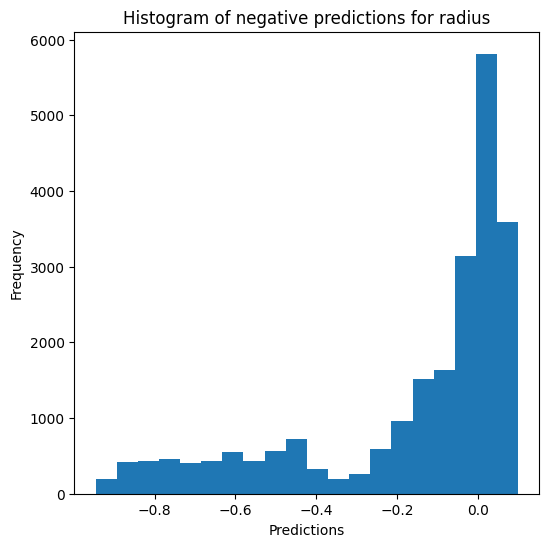

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998794439590657
  RMSE :  0.033132818934927546
  MAE :  0.008790838897790296
  MedAE :  0.00028000000000100167
  CORR :  0.9999397325161002
  MAX_ER :  0.7721799999999934
  Percentiles : 
    75th percentile :  0.003489999999989113
    90th percentile :  0.01952500000001134
    95th percentile :  0.04385999999999979
    99th percentile :  0.15145299999999748

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999972789283672
  RMSE :  0.017489908006989612
  MAE :  0.006992004430152127
  MedAE :  0.000690000000002744
  CORR :  0.9999864682248569
  MAX_ER :  0.5003700000000038
  Percentiles : 
    75th percentile :  0.007470000000004529
    90th percentile :  0.020973000000001945
    95th percentile :  0.032939500000000635
    99th percenti

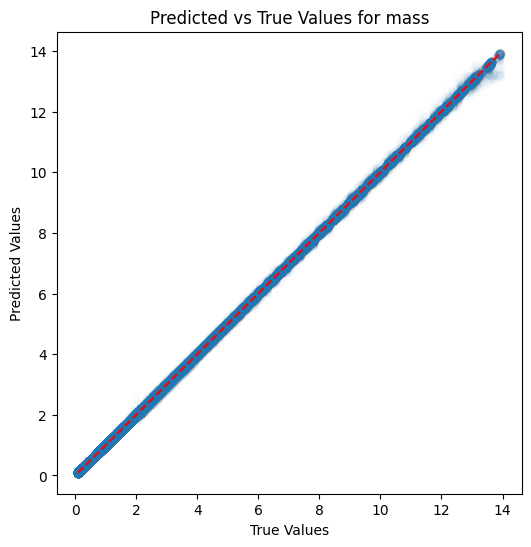

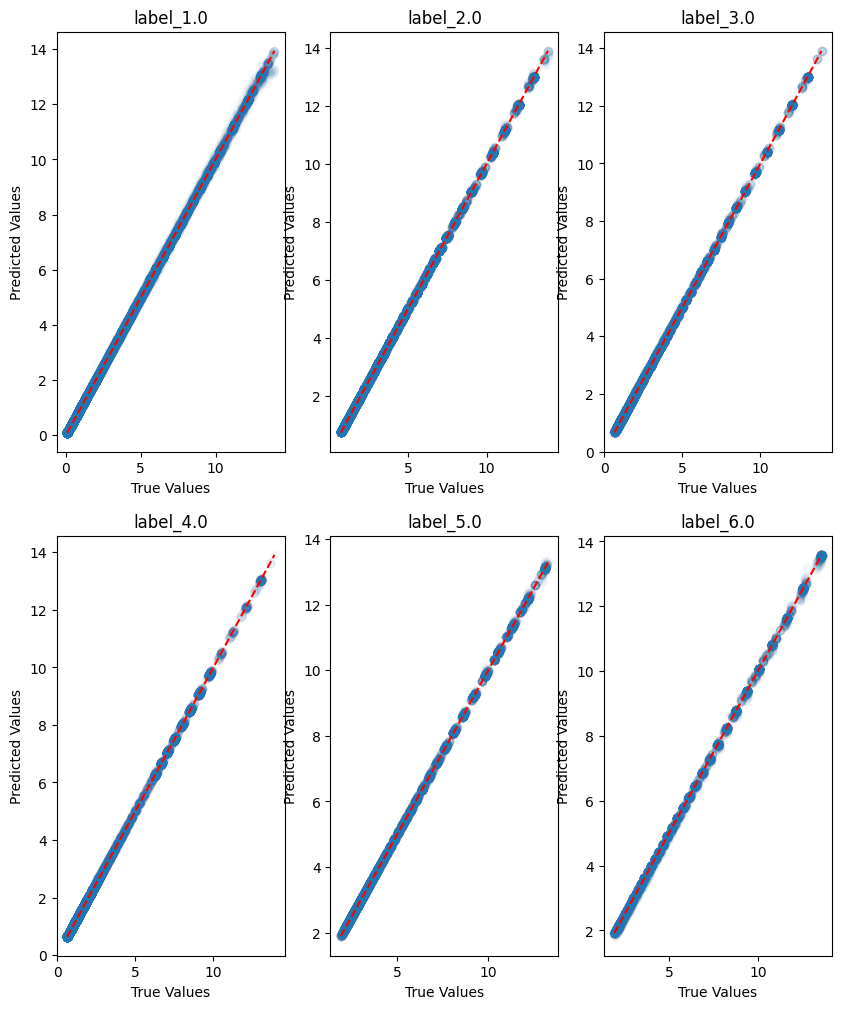

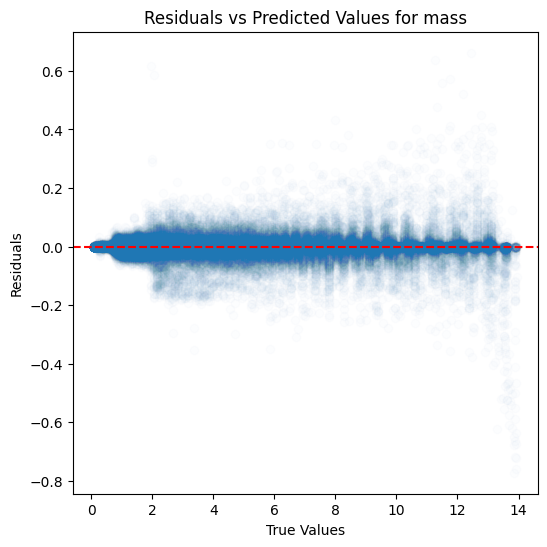

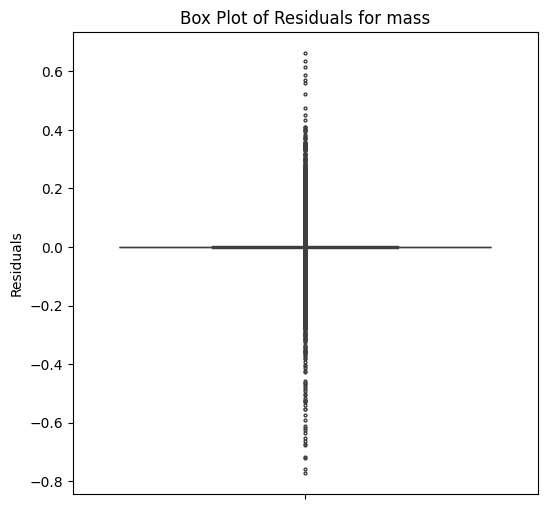

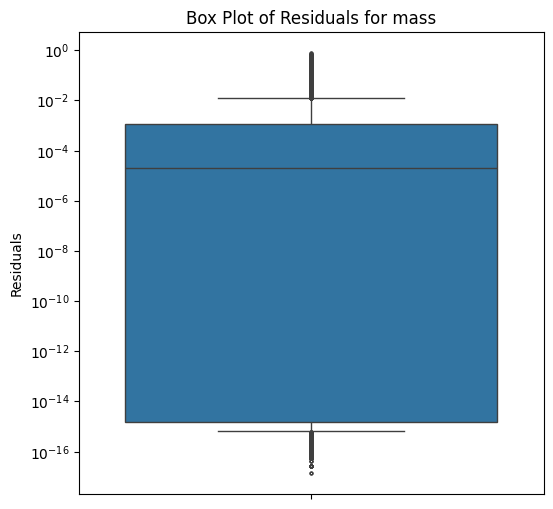

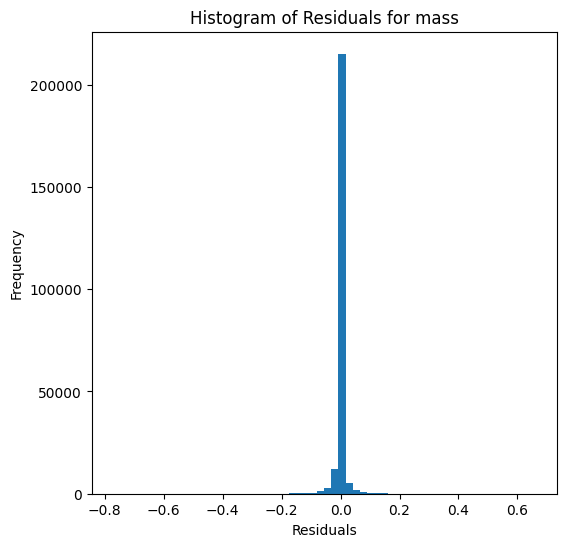

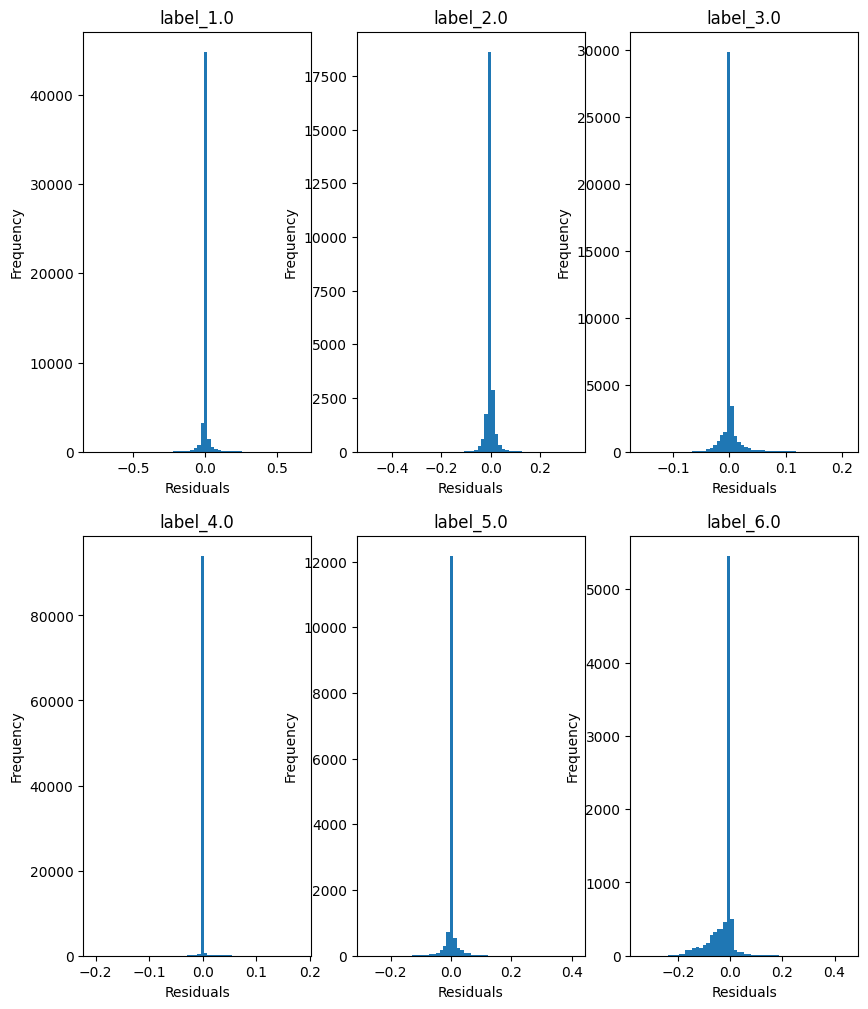

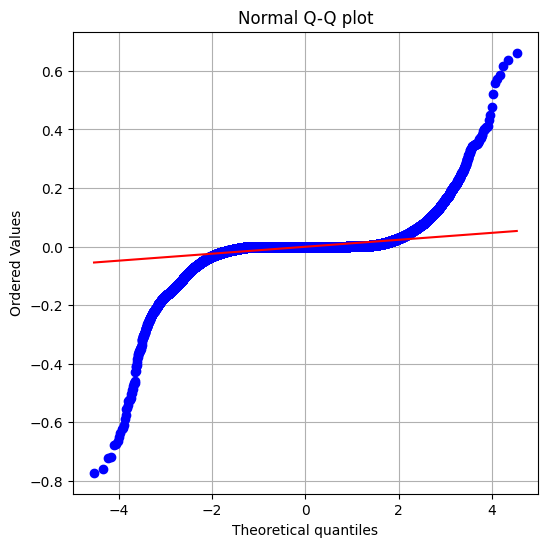

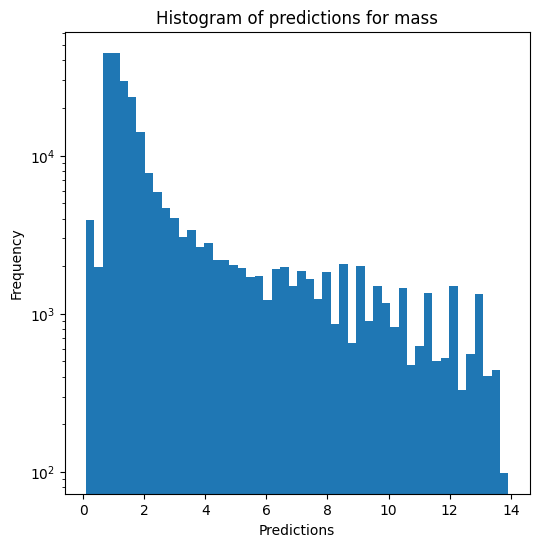

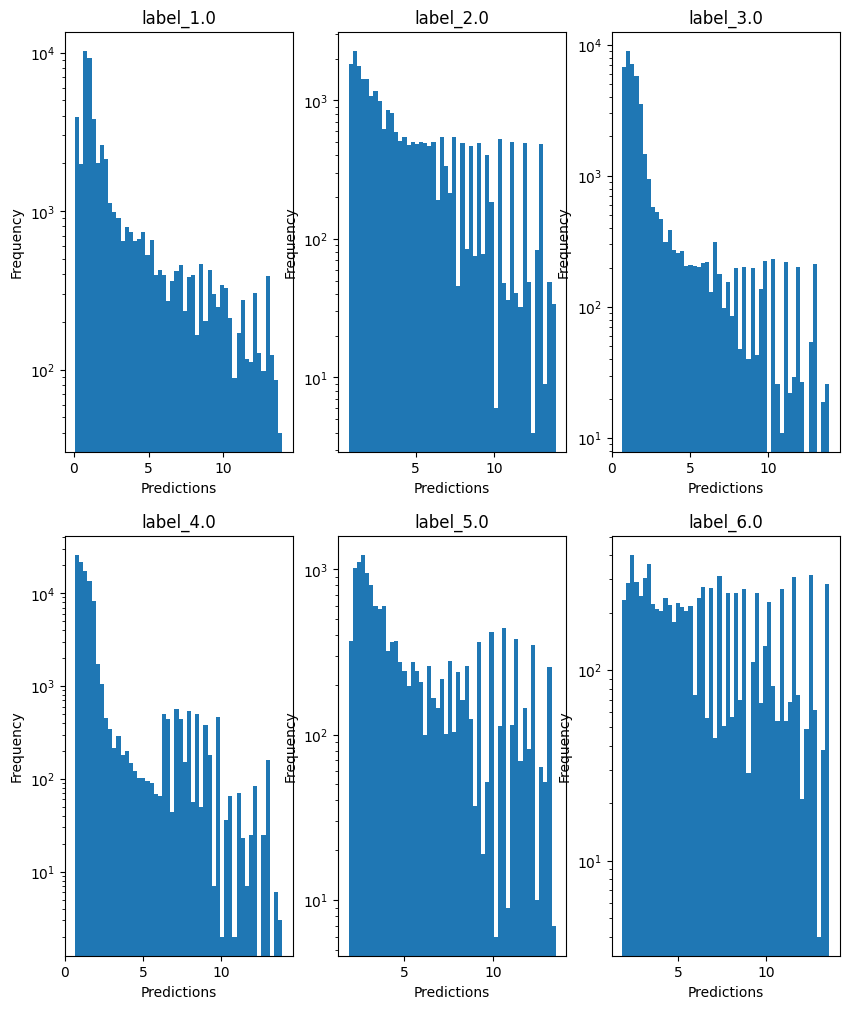

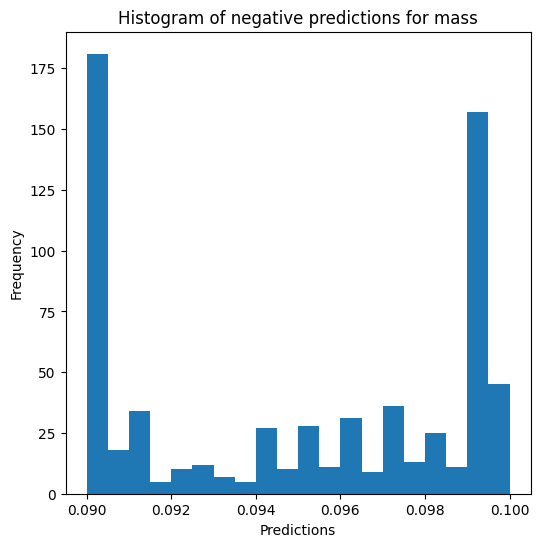


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999176946079099
  RMSE :  0.003320223510204656
  MAE :  0.0013269683135573717
  MedAE :  0.00018814985959092825
  CORR :  0.9999589372876834
  MAX_ER :  0.07030300072439505
  Percentiles : 
    75th percentile :  0.001123108586041692
    90th percentile :  0.003943885847020934
    95th percentile :  0.006693011747670369
    99th percentile :  0.01463271931784695

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997511161978042
  RMSE :  0.00855523398085301
  MAE :  0.0029075268748154494
  MedAE :  0.00048500242966759144
  CORR :  0.9998800120777551
  MAX_ER :  0.27819186790989425
  Percentiles : 
    75th percentile :  0.0028396222878399047
    90th percentile :  0.007869611312163339
    95th percentile :  0.012126433781702941
    99th percentile :  0.029632403348519788

radius resul

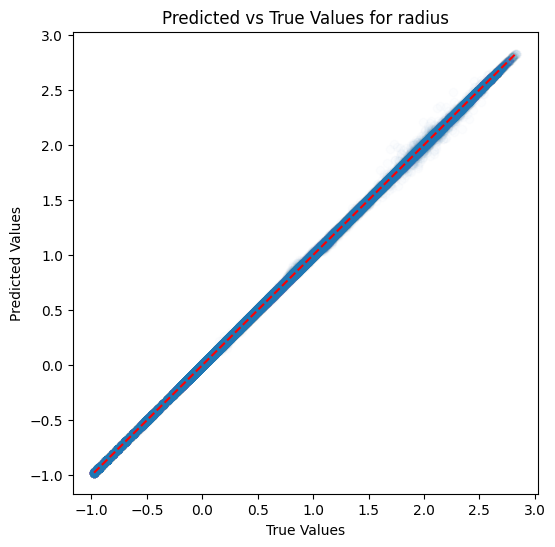

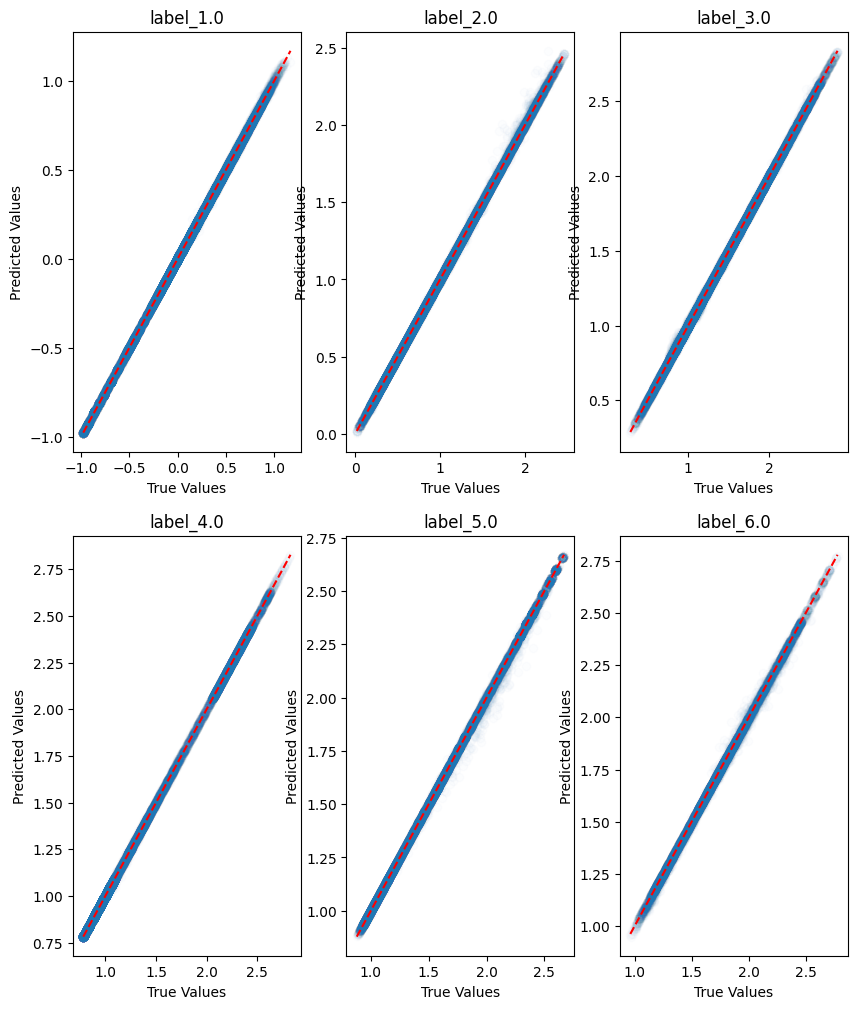

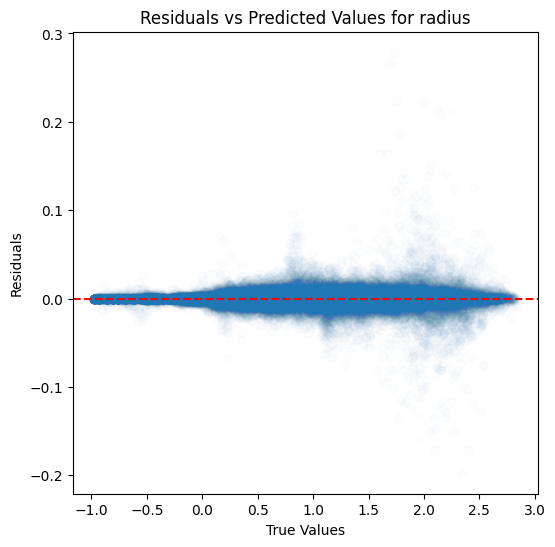

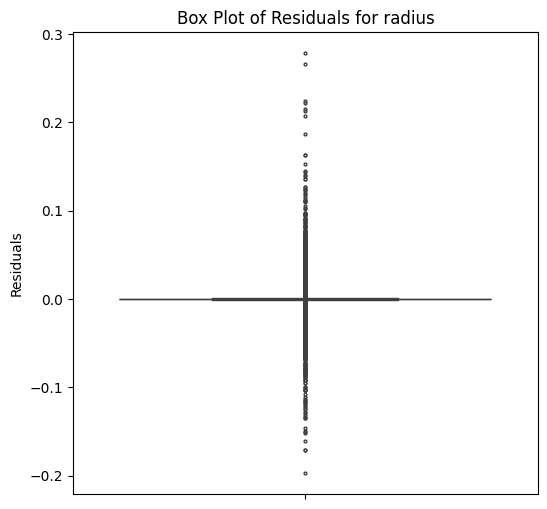

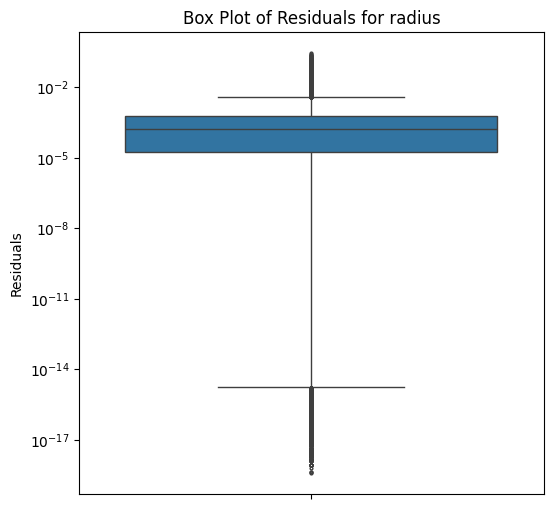

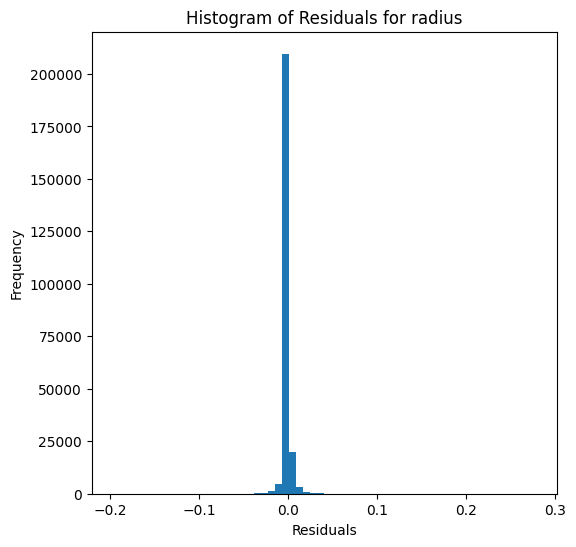

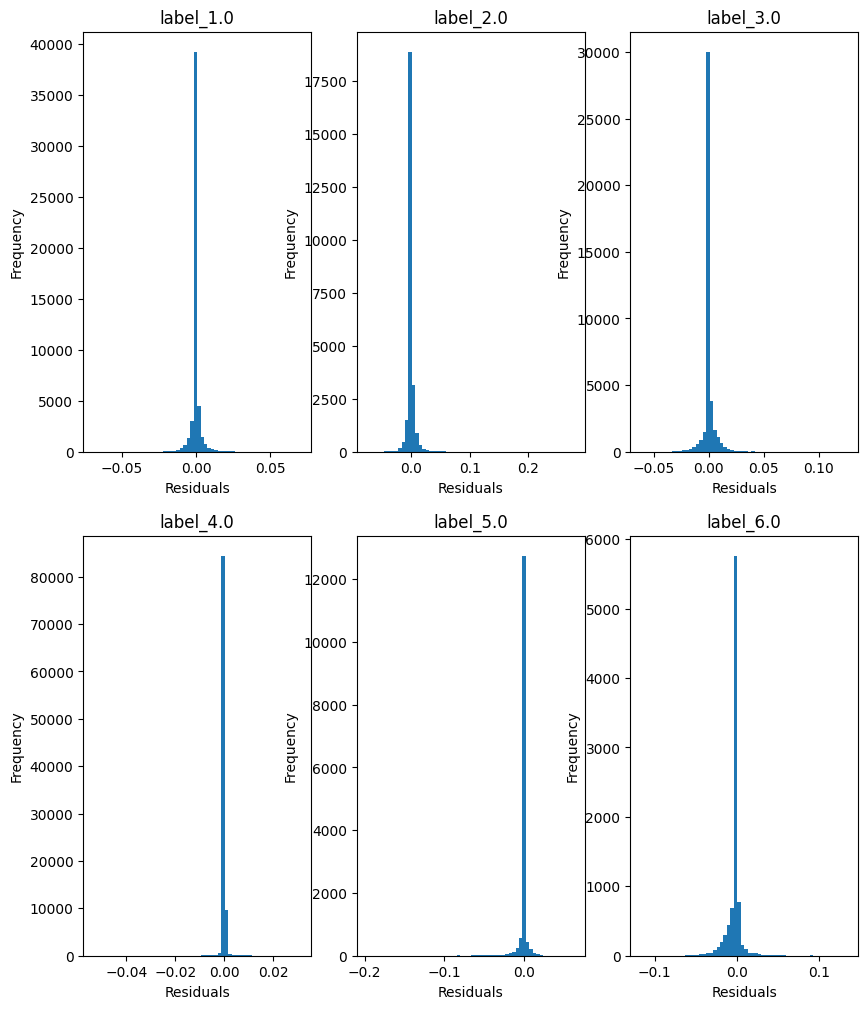

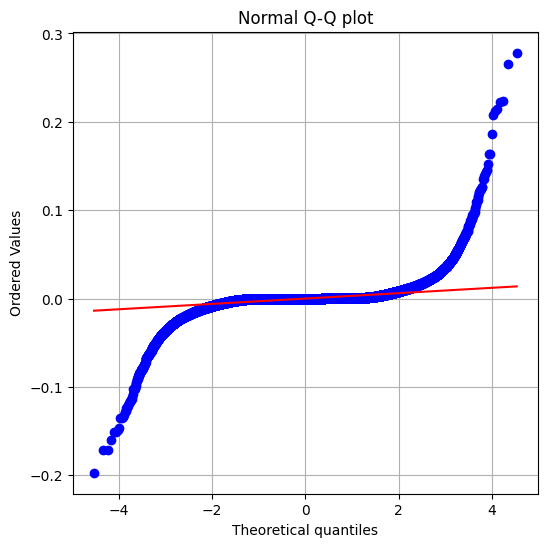

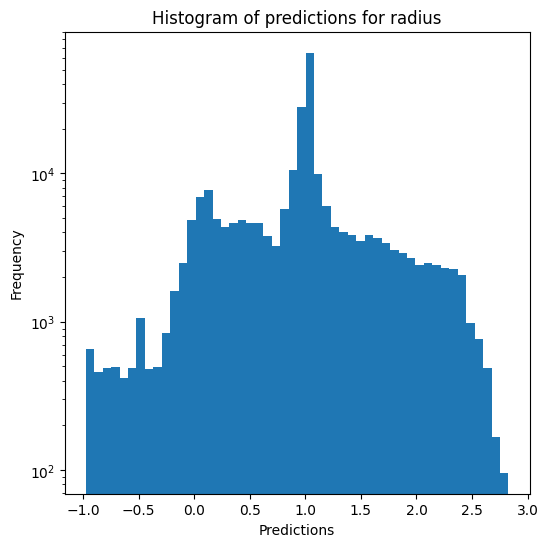

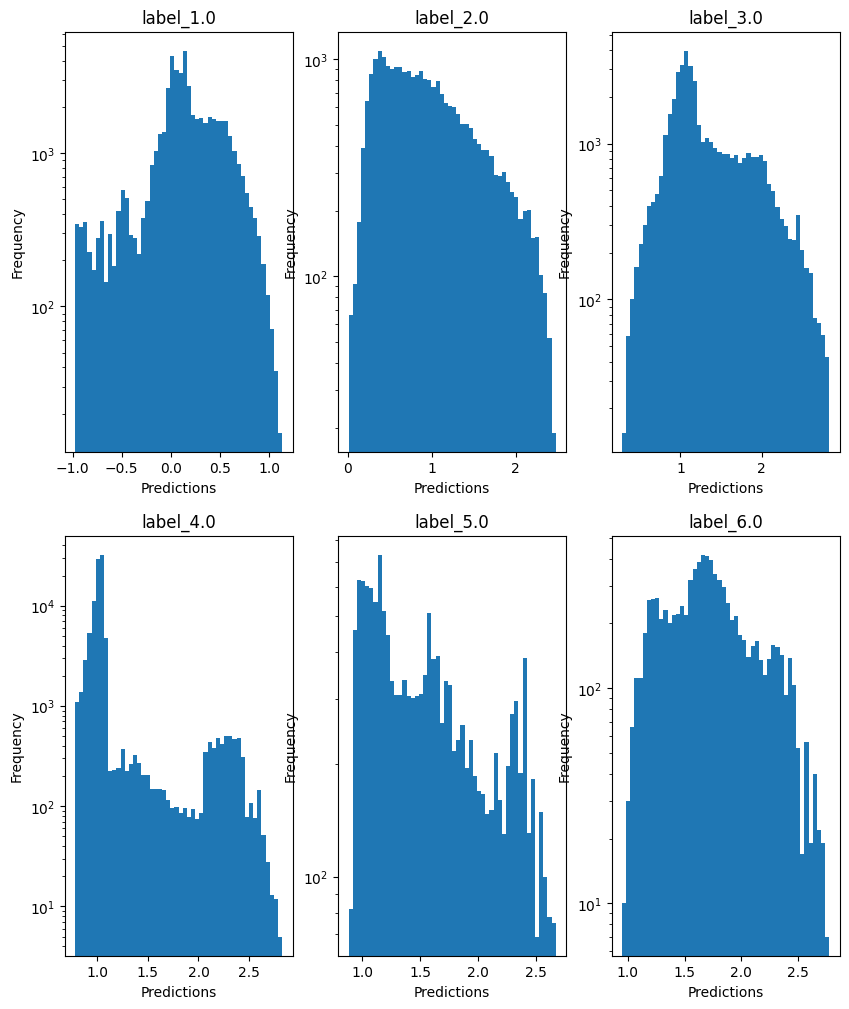

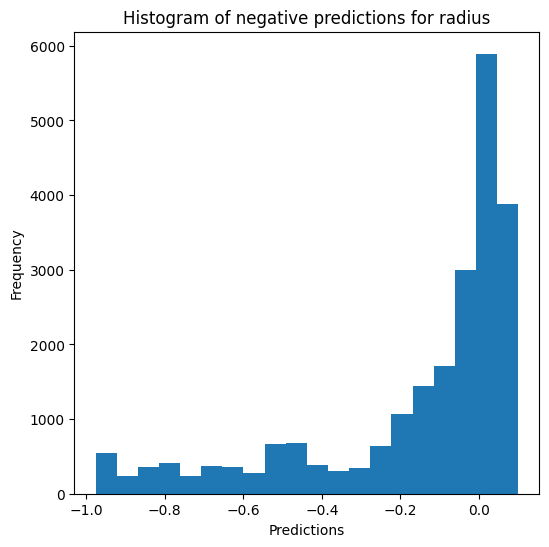

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991135273586226
  RMSE :  0.08985705838195406
  MAE :  0.04723612642455954
  MedAE :  0.02065684419870374
  CORR :  0.9995570767078075
  MAX_ER :  1.804158790588378
  Percentiles : 
    75th percentile :  0.05219232368469218
    90th percentile :  0.12139709472656257
    95th percentile :  0.18974626588821397
    99th percentile :  0.37235460205078136

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9998851377145733
  RMSE :  0.03649413101896139
  MAE :  0.0240373550104341
  MedAE :  0.014702699661255036
  CORR :  0.9999451751140391
  MAX_ER :  0.3696608276367179
  Percentiles : 
    75th percentile :  0.03153334903717053
    90th percentile :  0.05644210815429673
    95th percentile :  0.07855079994201661
    99th percentile :  0.1312

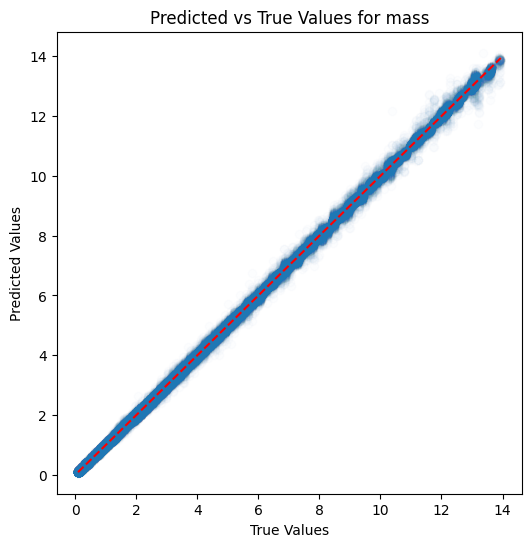

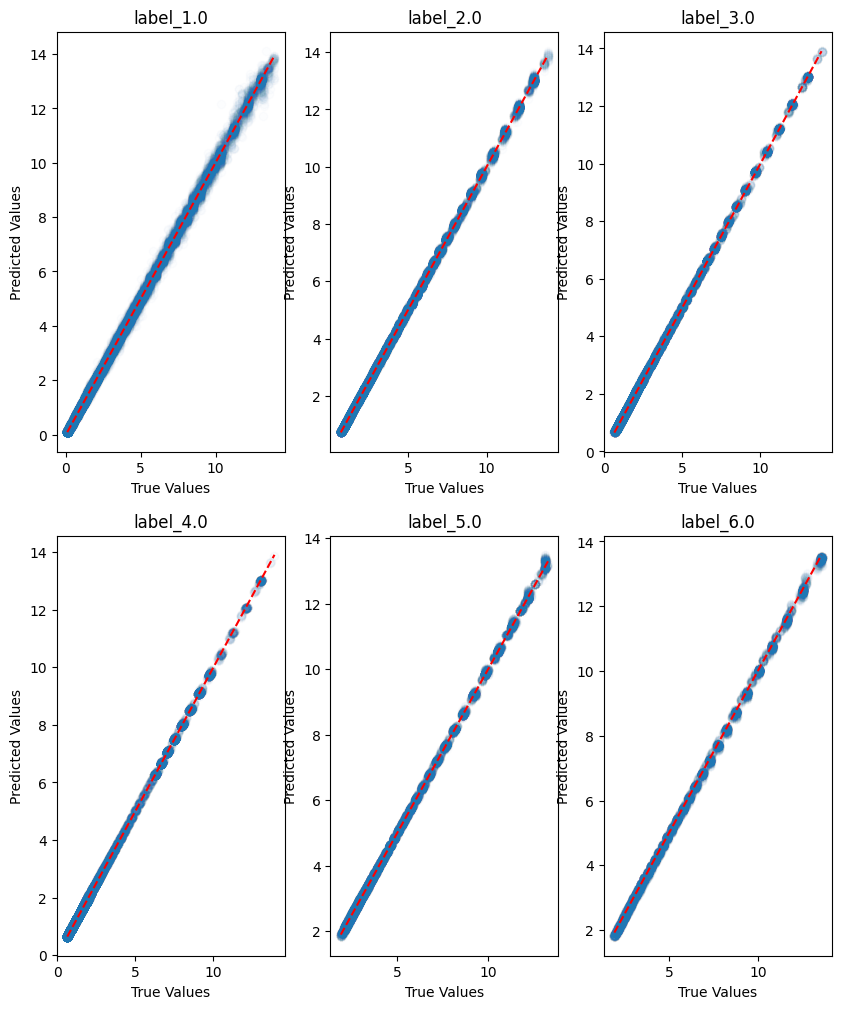

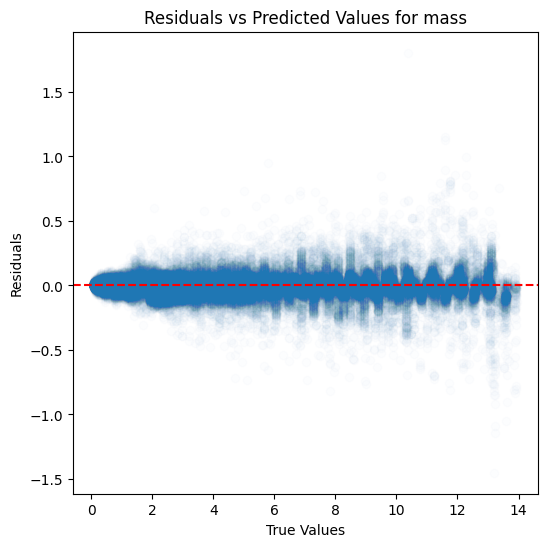

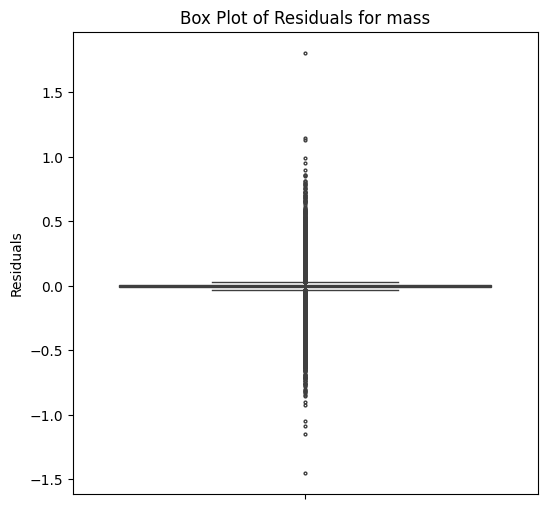

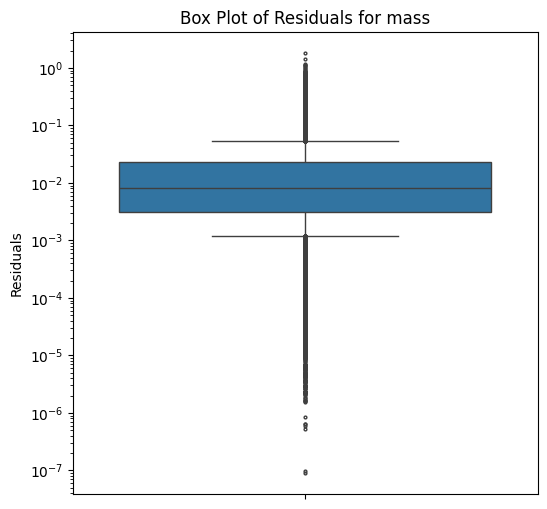

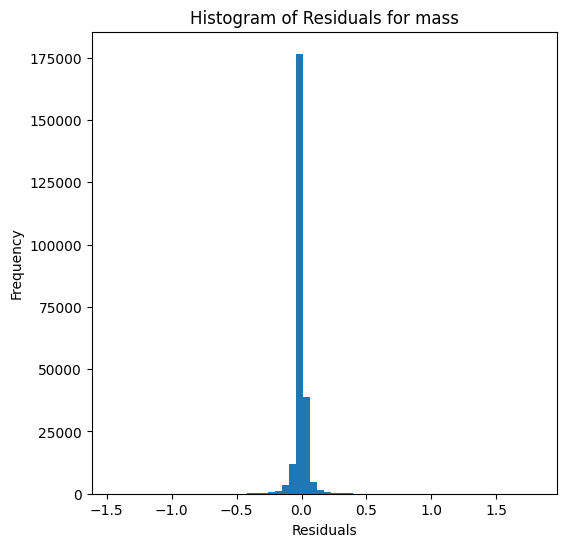

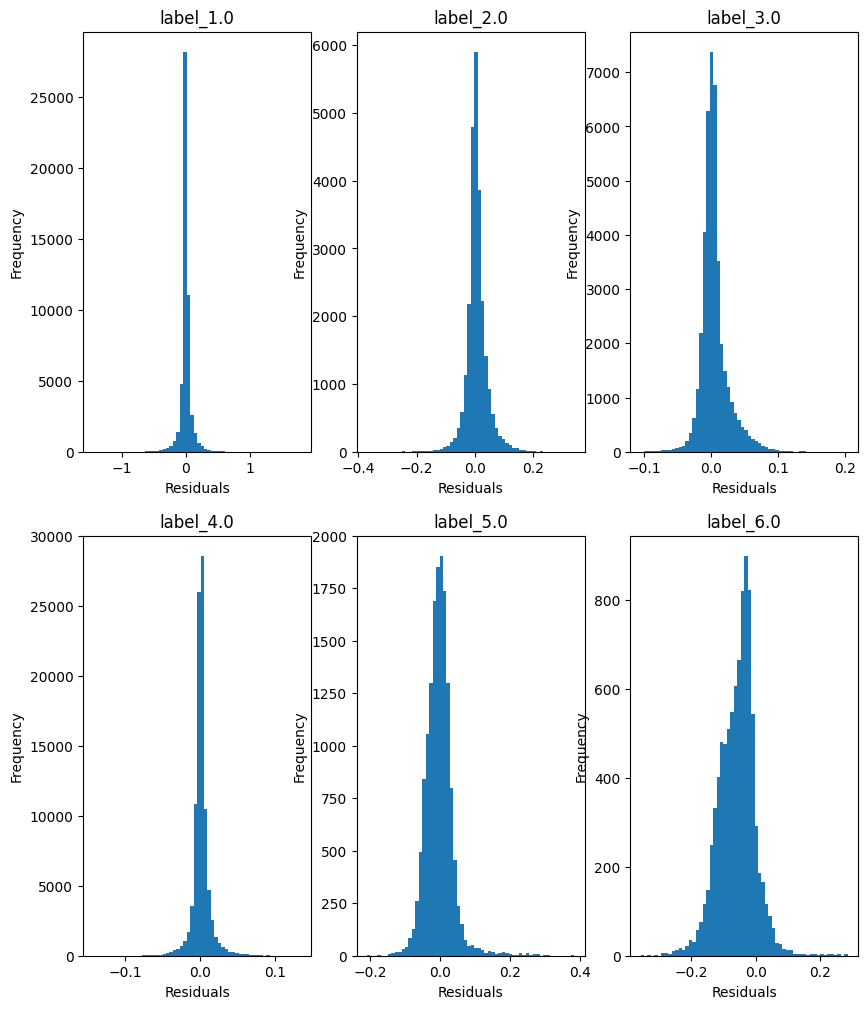

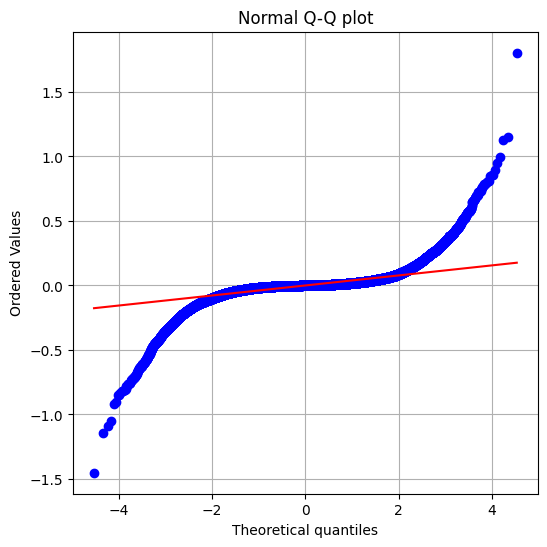

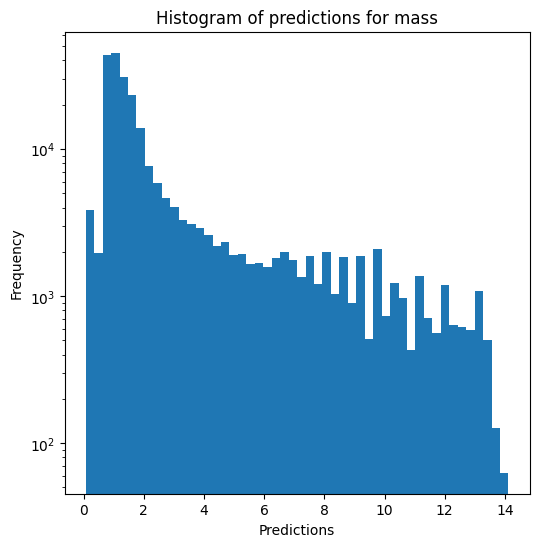

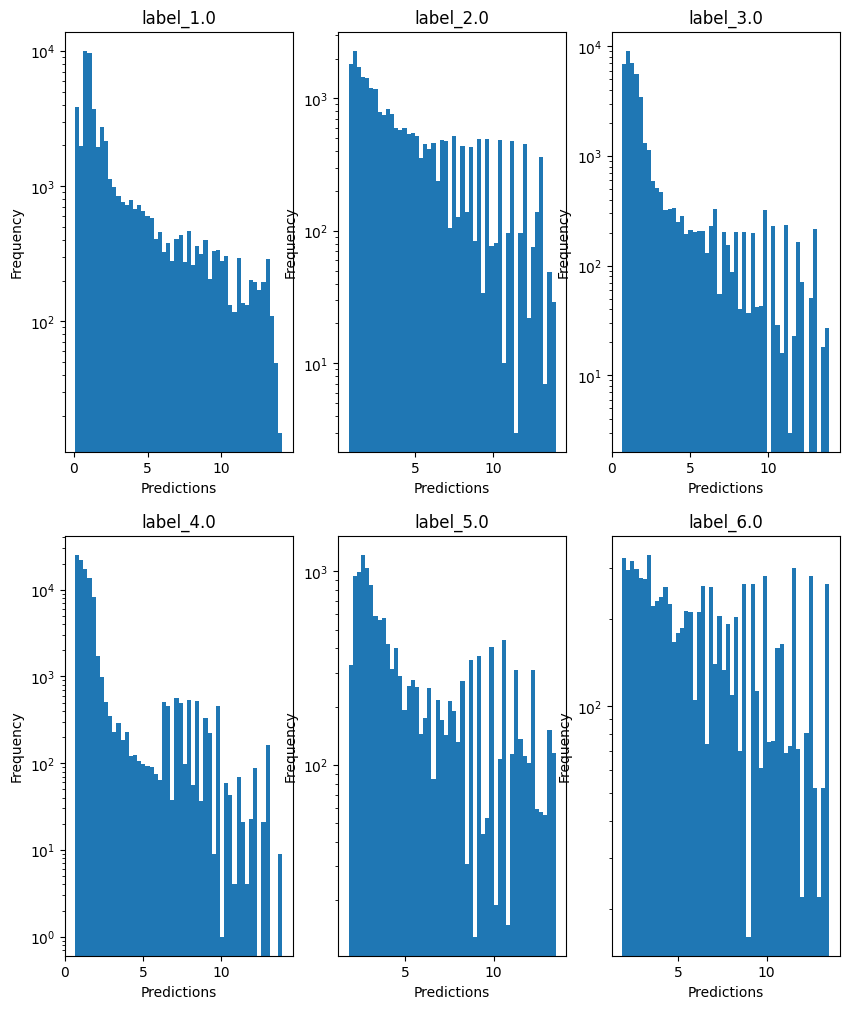

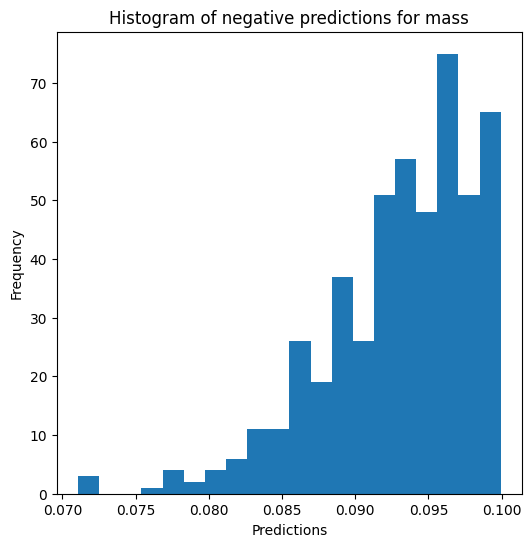


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9992511209598038
  RMSE :  0.01001530541480914
  MAE :  0.006845628123409734
  MedAE :  0.004697650280888227
  CORR :  0.9996255622957708
  MAX_ER :  0.09113250631773351
  Percentiles : 
    75th percentile :  0.009206419252331718
    90th percentile :  0.015147696953899364
    95th percentile :  0.02014407431968055
    99th percentile :  0.03528714356589568

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994268402582311
  RMSE :  0.012997343808250805
  MAE :  0.009688294751873607
  MedAE :  0.007639111715512084
  CORR :  0.9997203421407704
  MAX_ER :  0.14895137880407328
  Percentiles : 
    75th percentile :  0.013383492080228765
    90th percentile :  0.020336261792165928
    95th percentile :  0.025118520080813698
    99th percentile :  0.03892351490965327

radius results for th

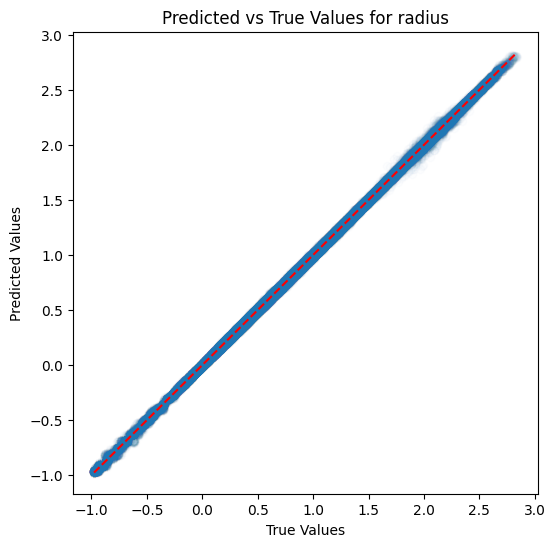

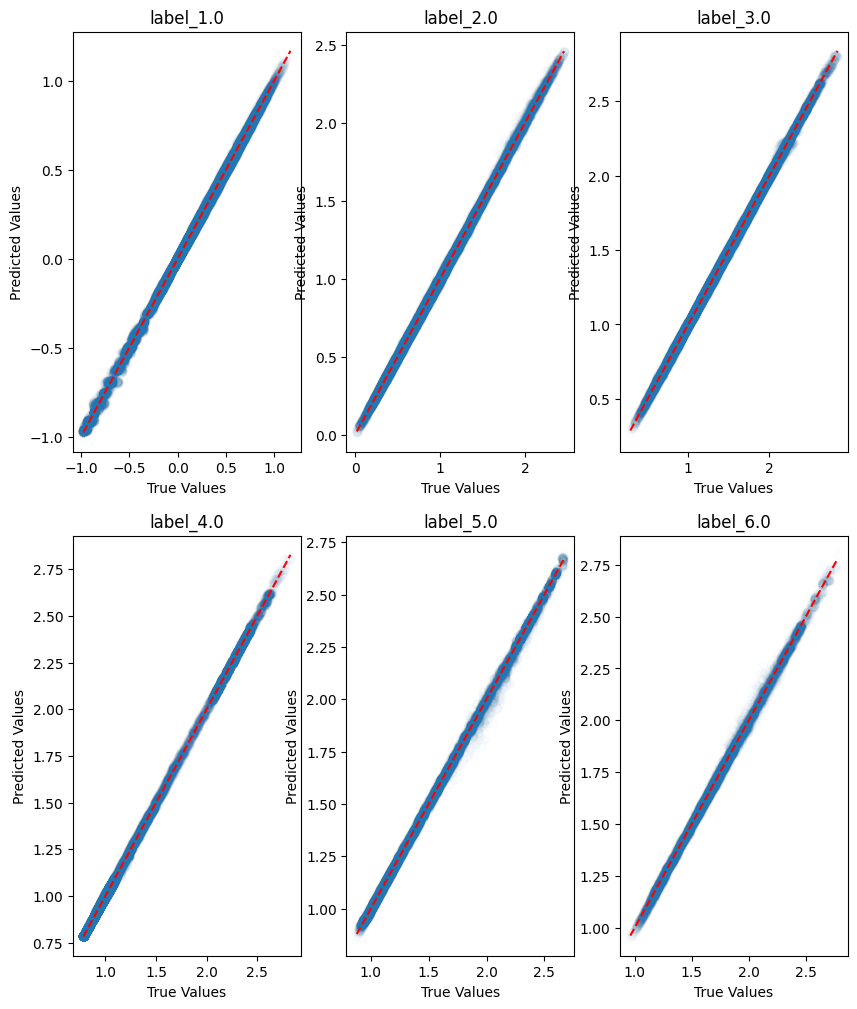

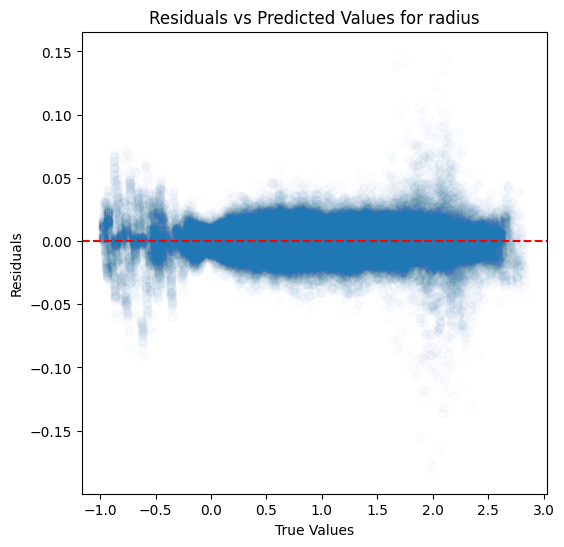

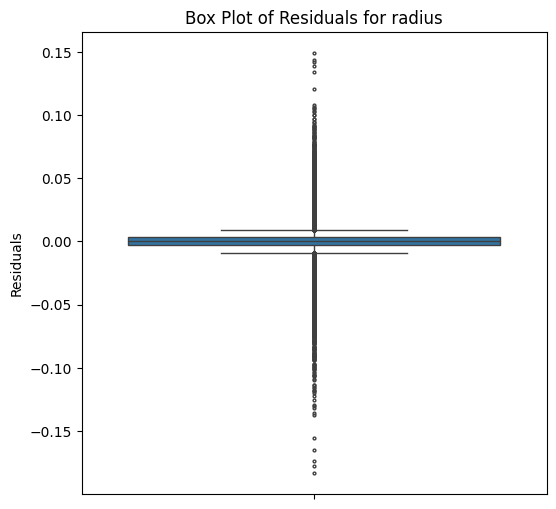

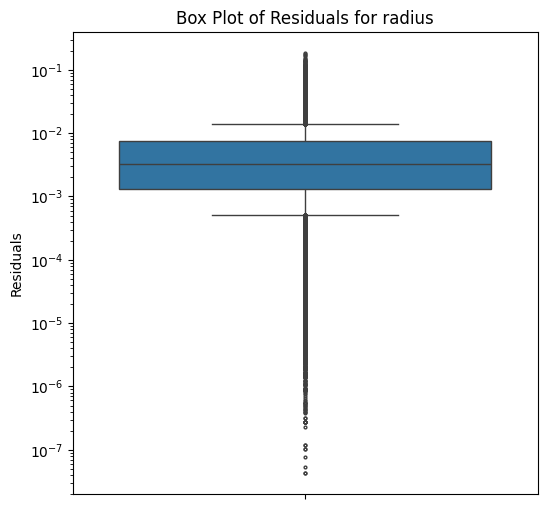

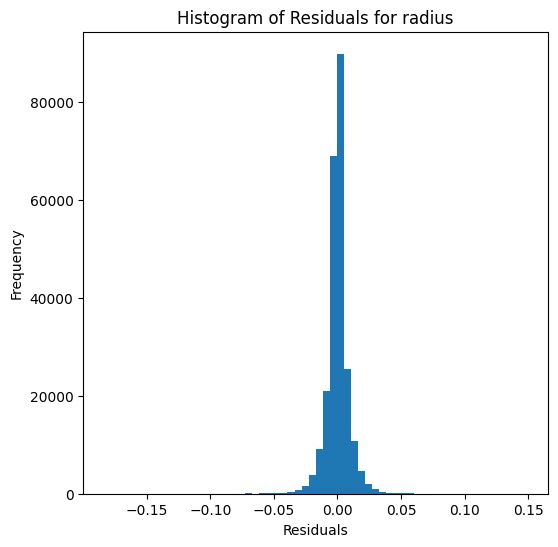

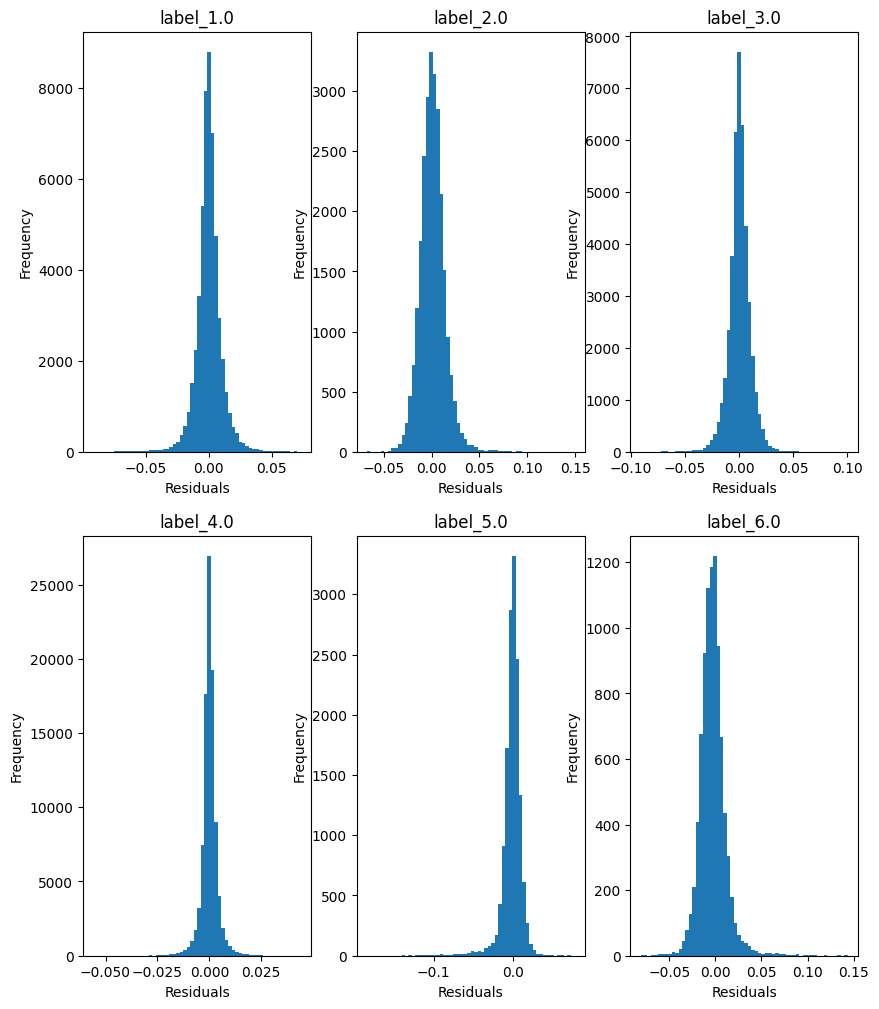

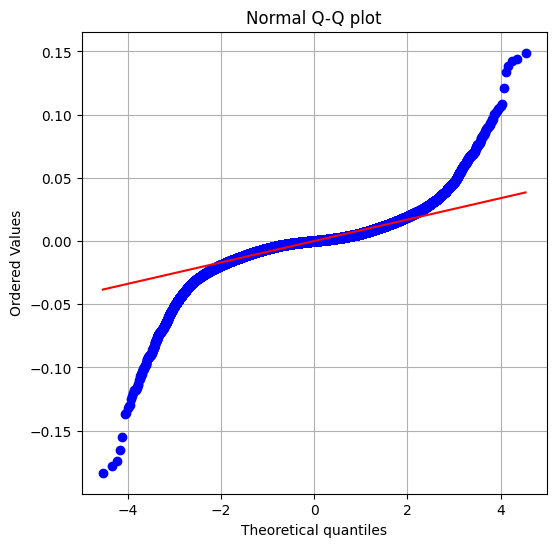

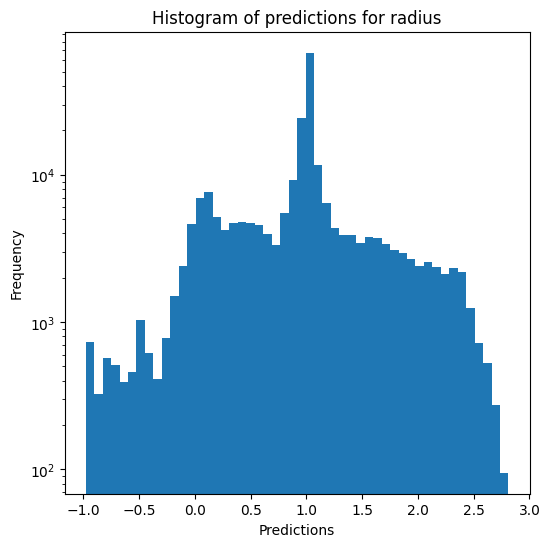

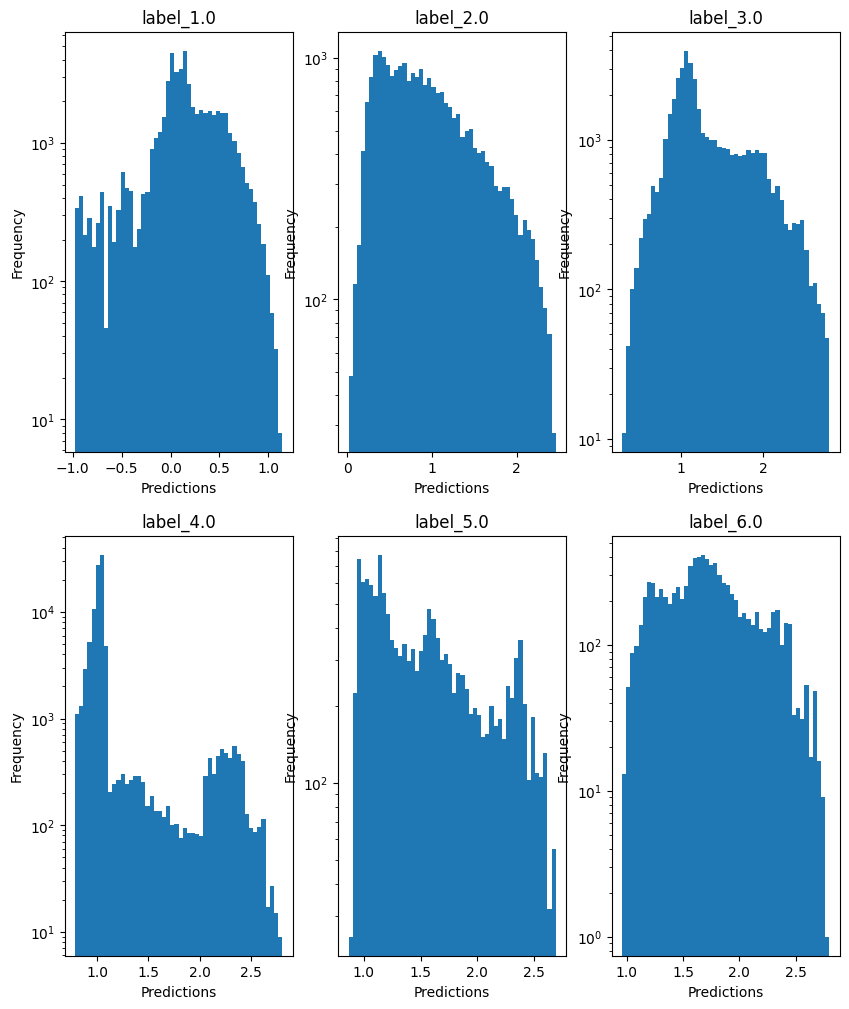

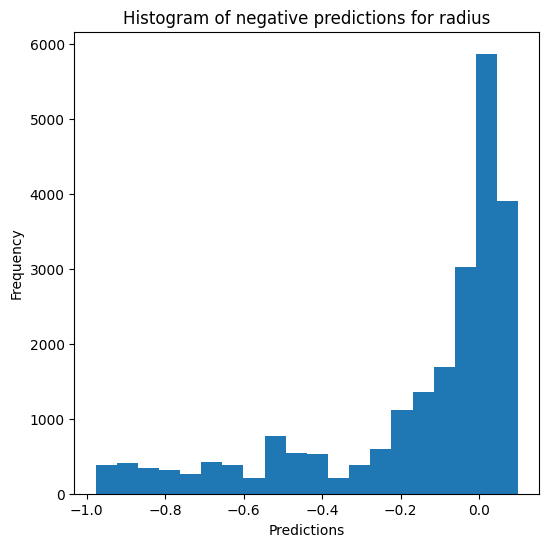

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0021908603422870956
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.002154825206338899
3 

...

0.0031086286383357697
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0027866868469002873
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0025362490764314917

Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9976170363577135
  RMSE :  0.14855330990957039
  MAE :  0.0806774187788967
  MedAE :  0.041093077526569544
  CORR :  0.9988104275907146
  MAX_ER :  2.144614817272739
  Percentiles : 
    75th percentile :  0.08935037229239087
    90th percentile :  0.19113860577894148
    95th percentile :  0.29465458363328545
    99th percentile :  0.6292008374733211

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9993508573776295
  RMSE :  0.08604605637974817
  MAE :  0.060424214205637636
  MedAE :  0.041039702956943924
  CORR :  0.9996790666473924
  MAX_ER :  0.7845065732246148
  Percentiles : 
    75th percentile :  0.08235810616458683
    90th percentile :  0.13955838883258168
    95th percentile :  0.18045277067397122
    99th percentile :  0.2880055789912122

mass results for the label category with

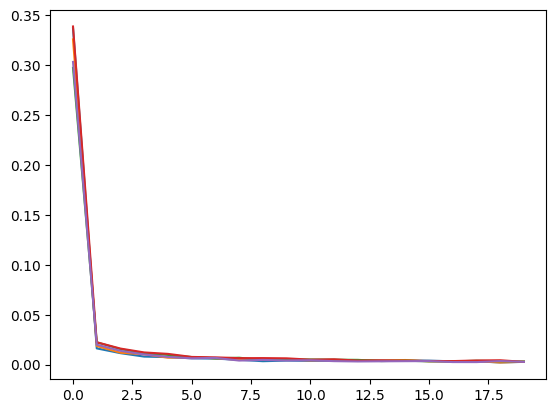

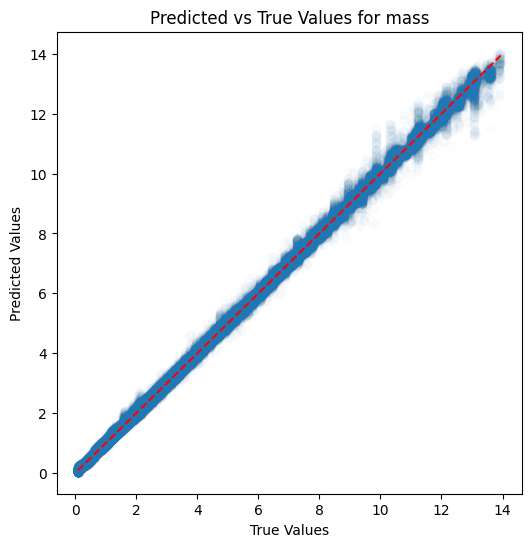

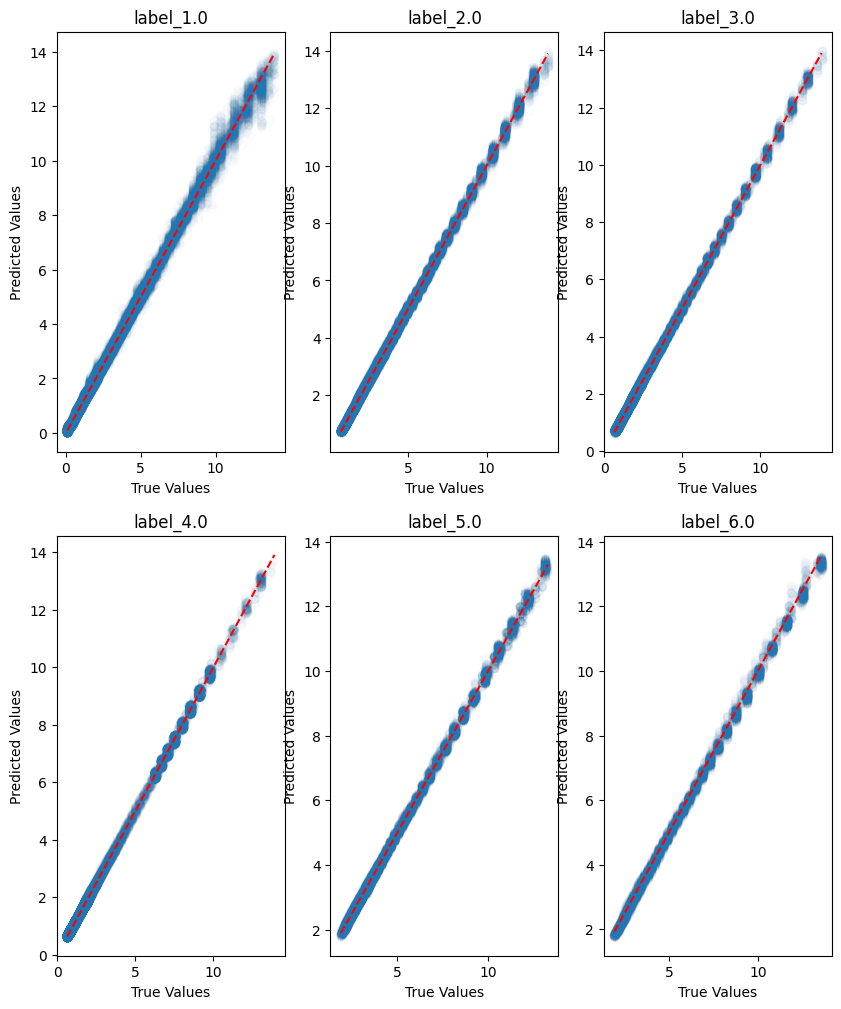

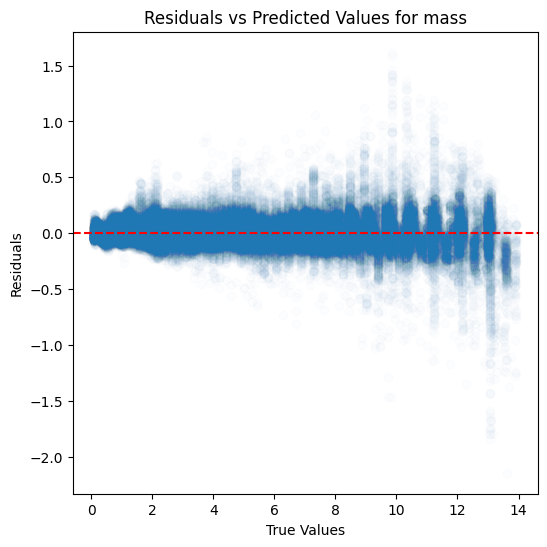

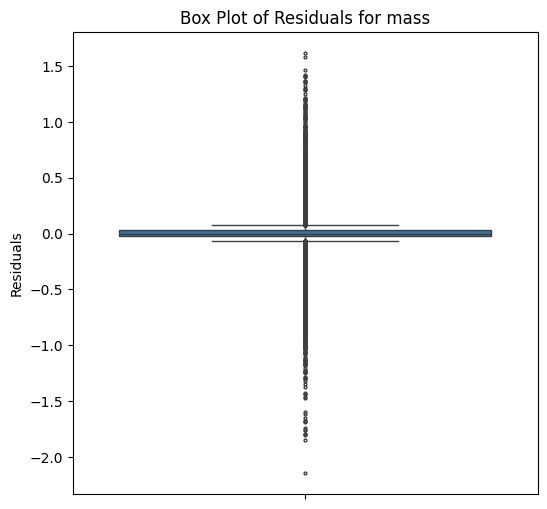

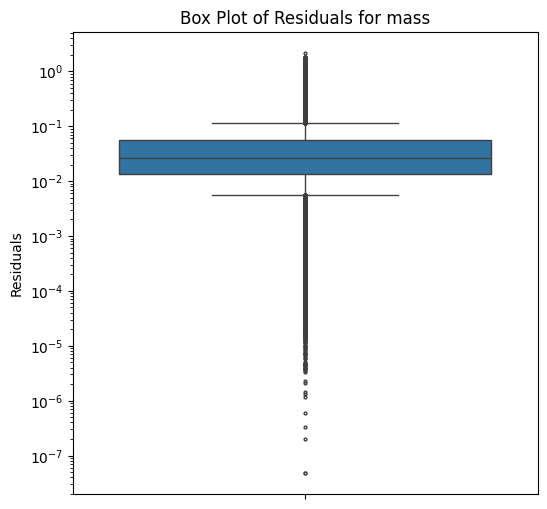

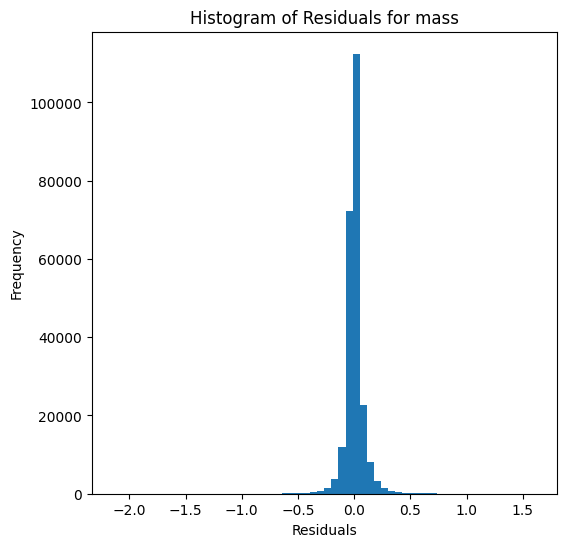

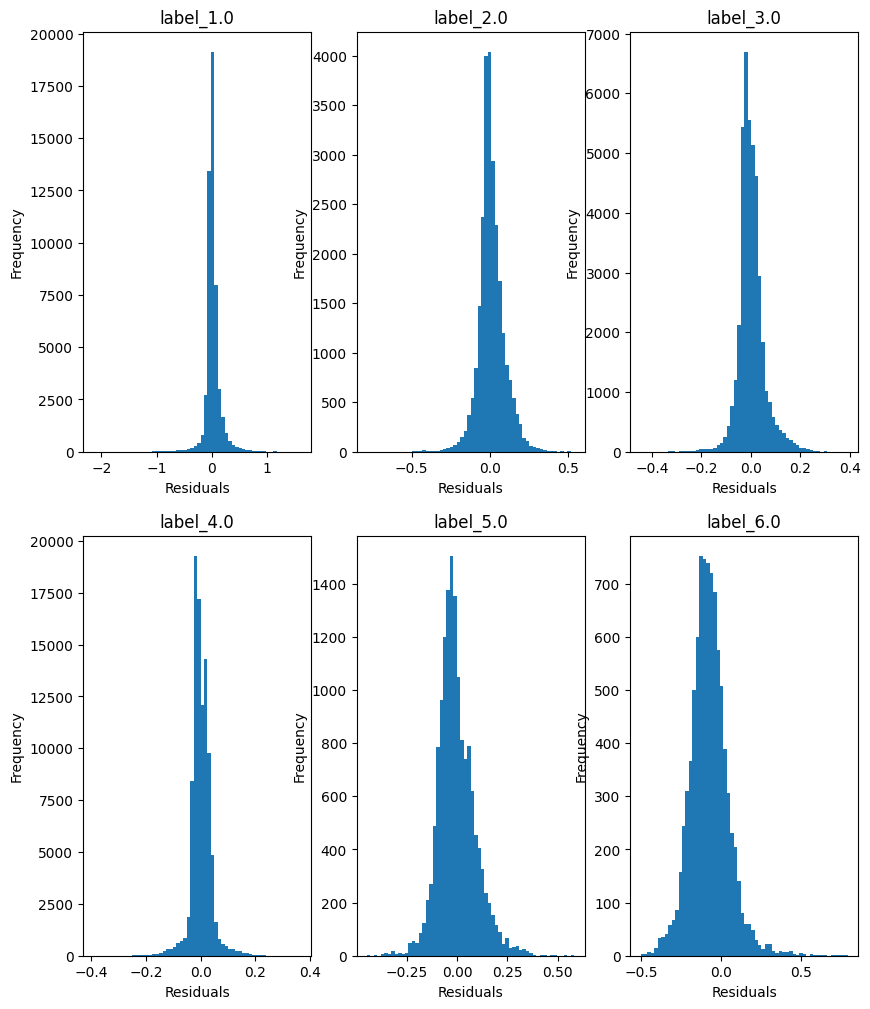

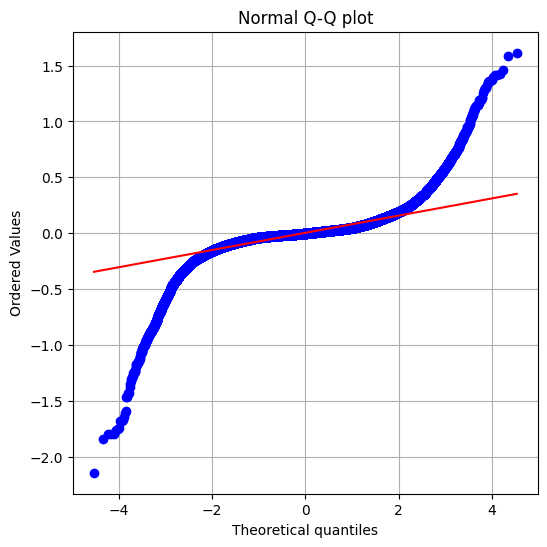

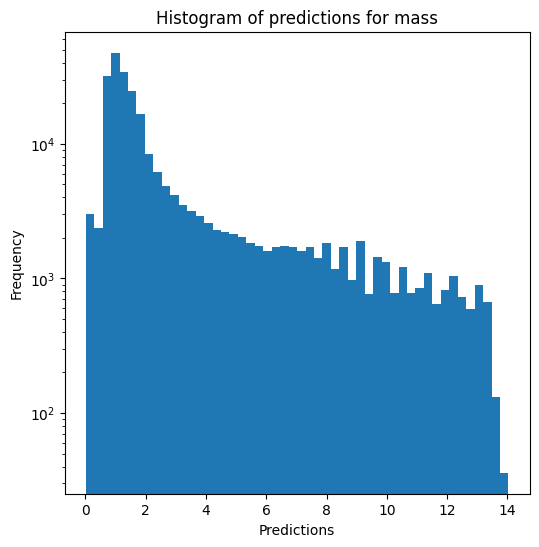

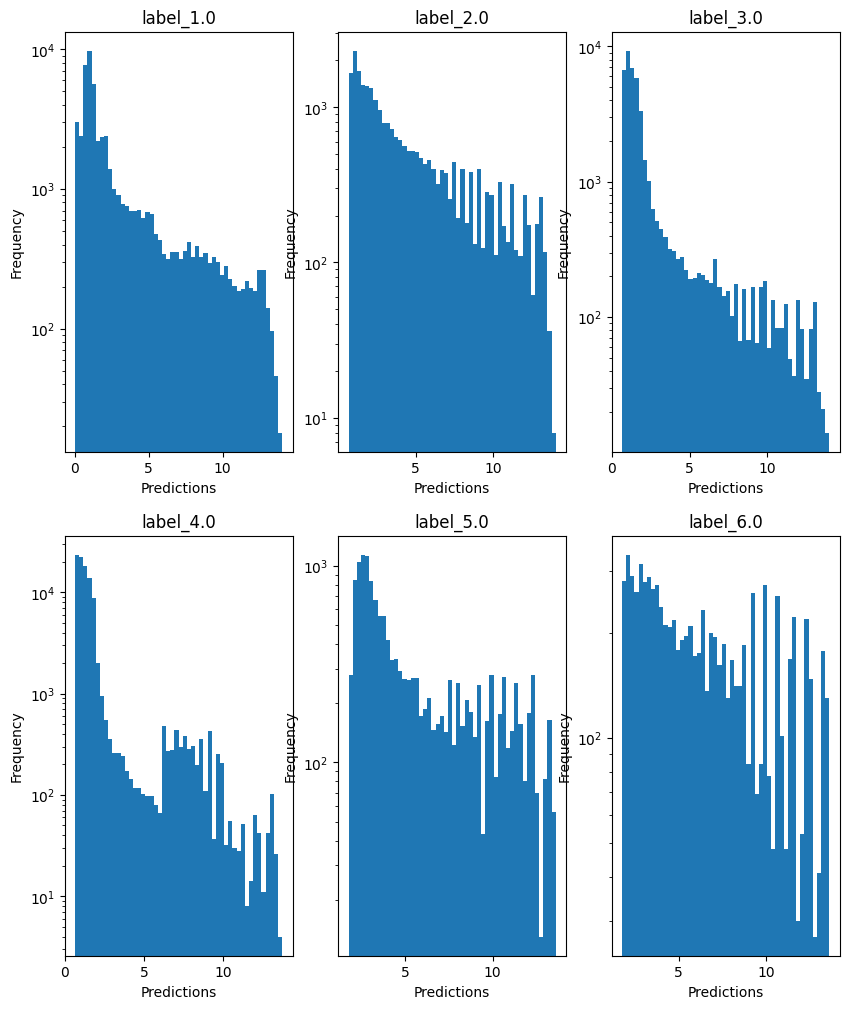

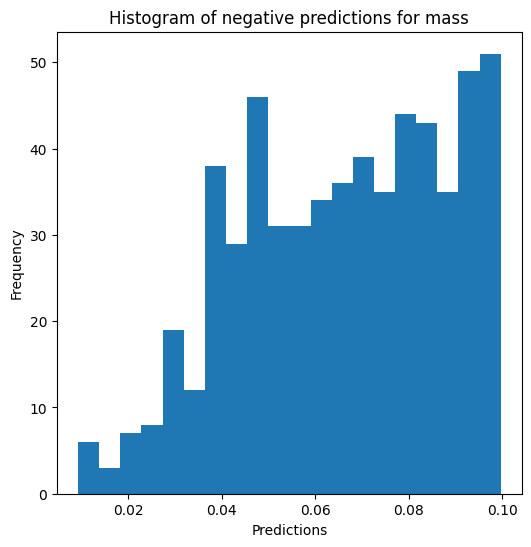


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9908612921814748
  RMSE :  0.03512870425565068
  MAE :  0.026445414955990596
  MedAE :  0.021098808759591026
  CORR :  0.995737923286811
  MAX_ER :  0.21766728060276075
  Percentiles : 
    75th percentile :  0.034409356678026276
    90th percentile :  0.05243027910303147
    95th percentile :  0.06918021993061144
    99th percentile :  0.12157825411600928

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.993941505127746
  RMSE :  0.04220646214044697
  MAE :  0.032326935533064254
  MedAE :  0.025374126448616918
  CORR :  0.9972310951724823
  MAX_ER :  0.18841827233894115
  Percentiles : 
    75th percentile :  0.0461627839520741
    90th percentile :  0.0706259151375163
    95th percentile :  0.08599219086343068
    99th percentile :  0.12108723663596334

radius results for the label c

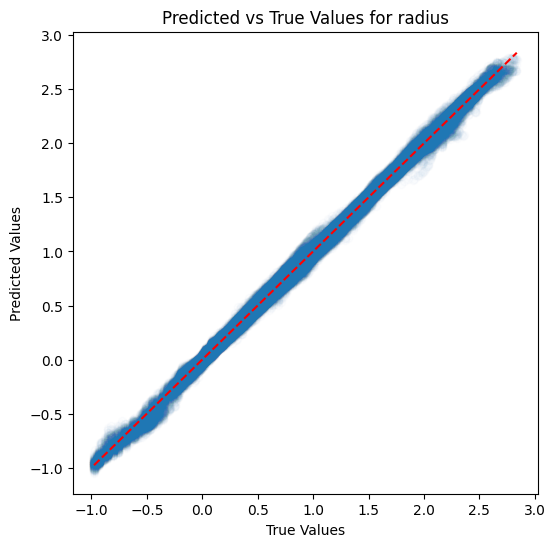

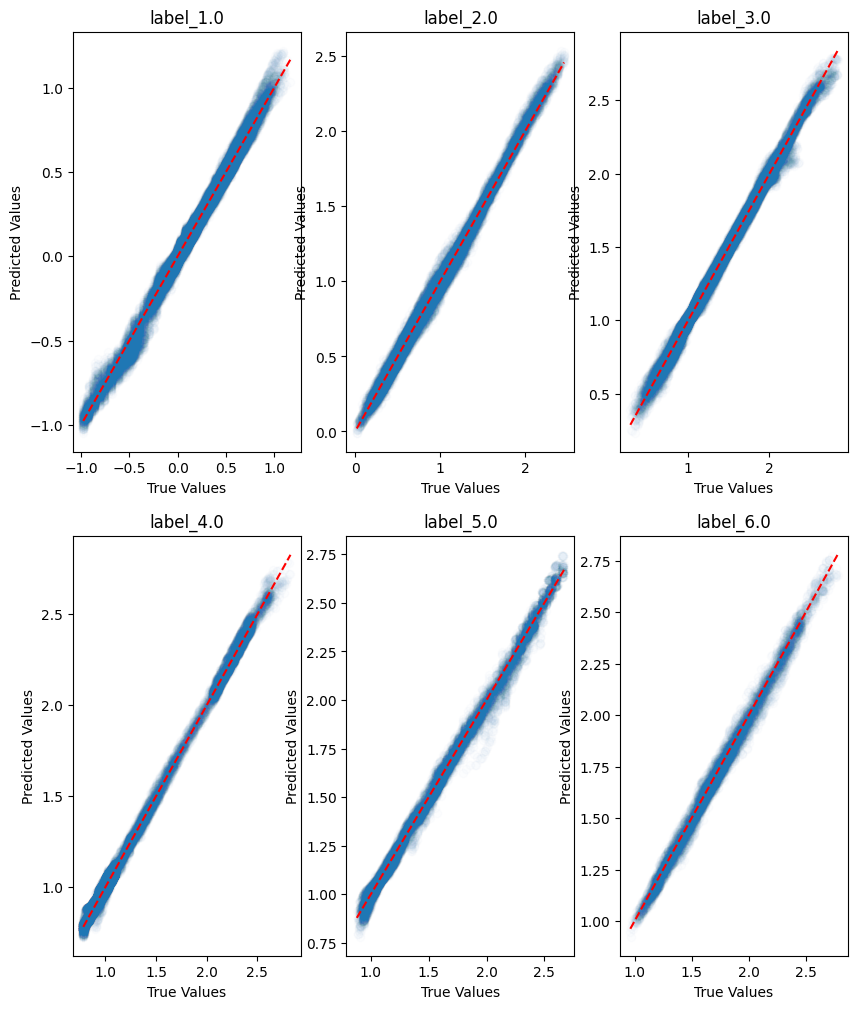

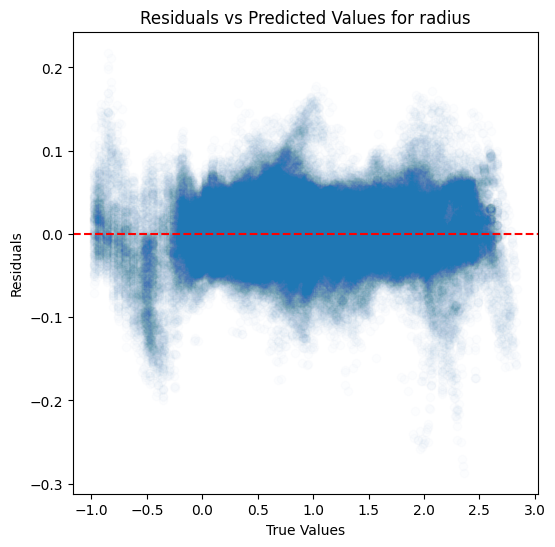

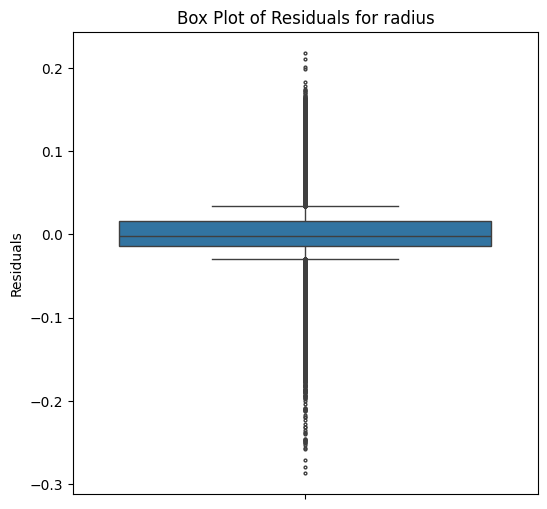

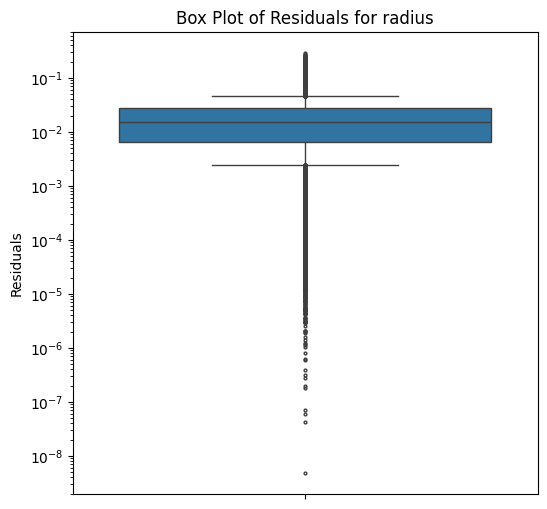

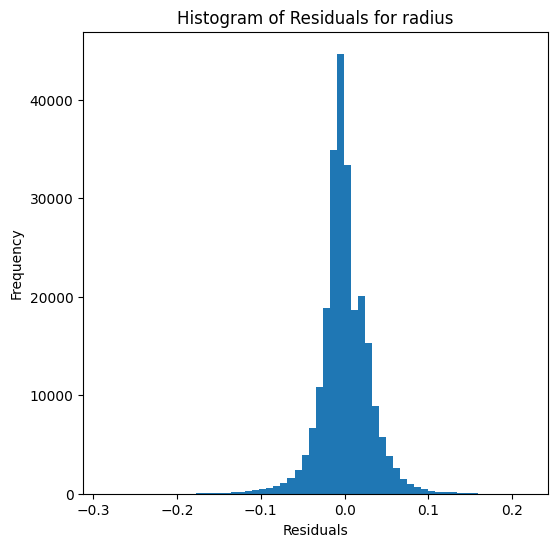

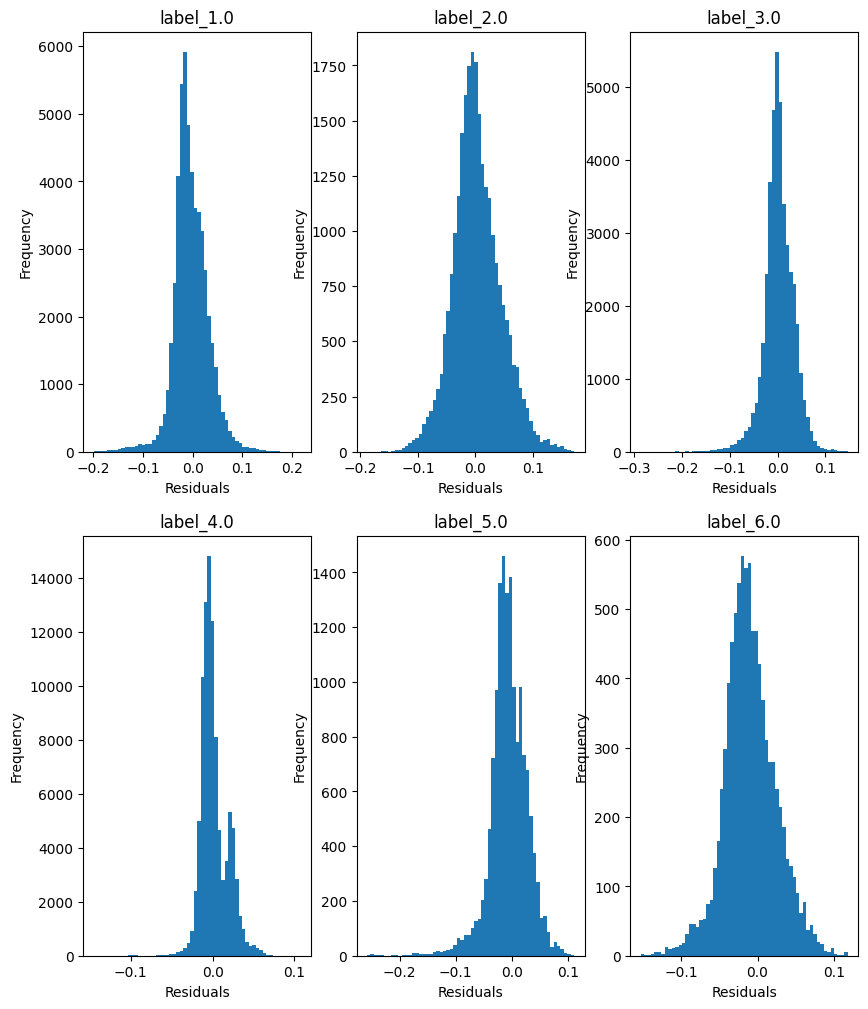

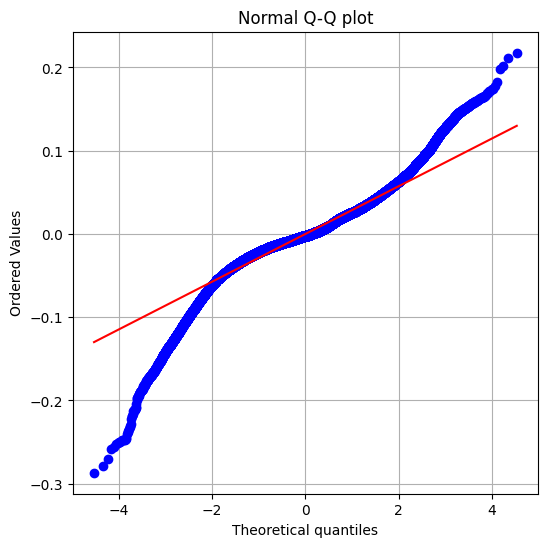

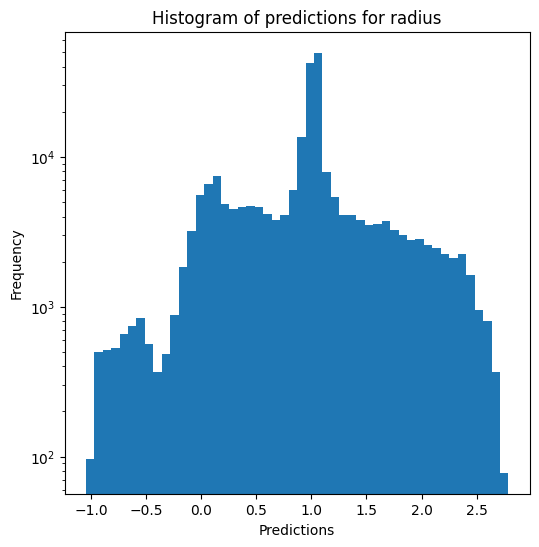

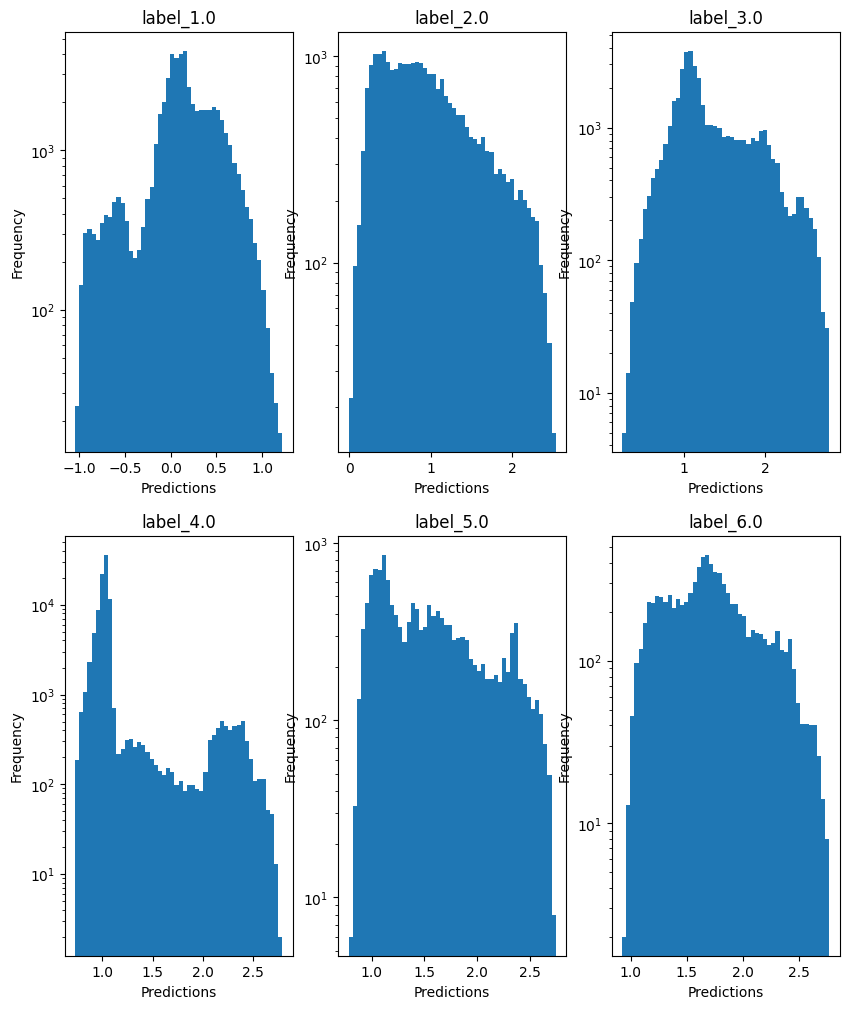

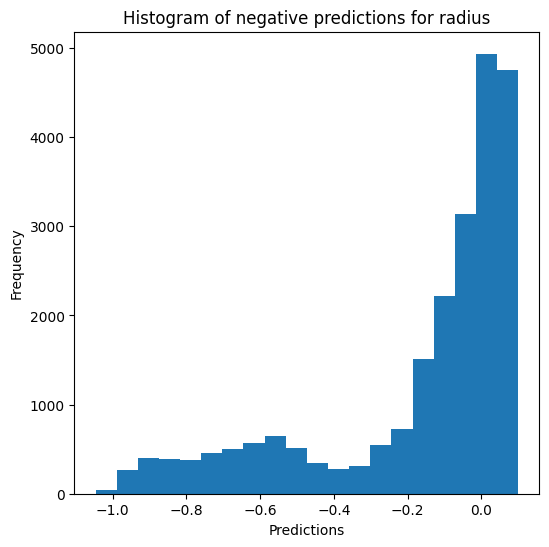

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon